# Ampliphi ML Take-Home: Data Exploration

This notebook helps you get started with the dataset. Feel free to modify it, extend it, or start fresh.

In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import seaborn as sns
import json
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

DATA_DIR = Path('../data')

## 1. Load the Data

In [209]:
# Reservations
reservations = pd.read_csv(DATA_DIR / 'reservations.csv', parse_dates=['booking_date', 'stay_date', 'checkout_date'])
print(f'Reservations: {len(reservations):,} rows')
display(reservations.head())
display(reservations.describe())

Reservations: 312,501 rows


,reservation_id,property_id,room_type,booking_date,stay_date,checkout_date,length_of_stay,lead_time_days,status,num_guests
0,property_A_R0000001,property_A,standard_king,2021-09-09,2022-01-01,2022-01-02,1,114,completed,3
1,property_A_R0000002,property_A,premium_double,2021-12-18,2022-01-01,2022-01-02,1,14,completed,1
2,property_A_R0000003,property_A,economy,2021-12-31,2022-01-01,2022-01-13,12,1,completed,1
3,property_A_R0000004,property_A,standard_king,2021-12-26,2022-01-01,2022-01-04,3,6,completed,1
4,property_A_R0000005,property_A,standard_king,2021-12-25,2022-01-01,2022-01-02,1,7,completed,1


,booking_date,stay_date,checkout_date,length_of_stay,lead_time_days,num_guests
count,312501,312501,312501,312501.000000,312501.000000,312501.000000
mean,2023-10-27 06:12:20.618429,2023-12-16 08:03:09.111714,2023-12-19 04:32:43.692916,2.853872,50.076950,2.050067
min,2021-03-11 00:00:00,2022-01-01 00:00:00,2022-01-02 00:00:00,1.000000,0.000000,1.000000
25%,2022-12-09 00:00:00,2023-02-05 00:00:00,2023-02-08 00:00:00,1.000000,5.000000,1.000000
50%,2023-11-11 00:00:00,2023-12-29 00:00:00,2024-01-01 00:00:00,2.000000,14.000000,2.000000
75%,2024-09-30 00:00:00,2024-11-19 00:00:00,2024-11-22 00:00:00,3.000000,53.000000,3.000000
max,2025-09-29 00:00:00,2025-09-29 00:00:00,2025-10-13 00:00:00,14.000000,299.000000,4.000000
std,NaN,NaN,NaN,2.455539,73.469924,0.920846


In [210]:
# Daily occupancy snapshots
occupancy = pd.read_csv(DATA_DIR / 'daily_occupancy.csv', parse_dates=['date'])
print(f'Daily occupancy: {len(occupancy):,} rows')
display(occupancy.head())

Daily occupancy: 15,048 rows


,property_id,date,room_type,total_rooms,rooms_occupied,occupancy_pct,pickup_last_day,available_rooms
0,property_A,2022-01-01,standard_king,120,36,0.3000,30,84
1,property_A,2022-01-01,standard_double,100,25,0.2500,26,75
2,property_A,2022-01-01,deluxe_king,80,13,0.1625,10,67
3,property_A,2022-01-01,suite,50,4,0.0800,4,46
4,property_A,2022-01-01,economy,60,19,0.3167,21,41


In [211]:
# Events
events = pd.read_csv(DATA_DIR / 'events.csv', parse_dates=['date'])
daily_events = pd.read_csv(DATA_DIR / 'daily_event_impacts.csv', parse_dates=['date'])
print(f'Events: {len(events):,} rows | Daily event impacts: {len(daily_events):,} rows')
display(events.head())

Events: 1,003 rows | Daily event impacts: 726 rows


,event_id,date,category,rank,attendance,predicted_accommodation_spend,impact_leading,impact_event_day,impact_lagging,duration_days
0,evt_1,2022-01-01,community,43,1661,32318,0.0832,0.3396,0.0352,1
1,evt_2,2022-01-01,sports,56,6553,136206,0.0618,0.4990,0.0888,1
2,evt_3,2022-01-10,sports,65,1454,12206,0.1866,0.3734,0.0909,1
3,evt_4,2022-01-09,festivals,82,2107,42354,0.2292,0.8129,0.1187,2
4,evt_4,2022-01-10,festivals,82,2107,42354,0.2292,0.8129,0.1187,2


In [212]:
daily_events.head()

,date,events_count,total_attendance,avg_rank,max_rank,total_accommodation_spend,impact_leading_total,impact_event_day_total,impact_lagging_total,has_major_event
0,2022-01-01,2,8214,49.5,56,168524,0.1450,0.8386,0.1240,0
1,2022-01-09,1,2107,82.0,82,42354,0.2292,0.8129,0.1187,0
2,2022-01-10,2,3561,73.5,82,54560,0.4158,1.1863,0.2096,0
3,2022-01-18,1,6487,31.0,31,121903,0.1201,0.1802,0.0272,0
4,2022-01-23,1,1519,98.0,98,48688,0.2652,0.4985,0.0527,1


In [213]:
# Property metadata
with open(DATA_DIR / 'property_metadata.json') as f:
    metadata = json.load(f)
    
for prop_id, info in metadata.items():
    print(f"\n{prop_id} ({info['location_type']}) — {info['total_rooms']} total rooms")
    for rt, rt_info in info['room_types'].items():
        print(f"  {rt}: {rt_info['inventory_count']} rooms")


property_A (urban_resort) — 450 total rooms
  standard_king: 120 rooms
  standard_double: 100 rooms
  deluxe_king: 80 rooms
  suite: 50 rooms
  economy: 60 rooms
  premium_double: 40 rooms

property_B (city_center) — 280 total rooms
  standard_queen: 90 rooms
  standard_king: 70 rooms
  deluxe_suite: 40 rooms
  economy: 50 rooms
  premium_king: 30 rooms


## 2. Reservation Patterns

### 2.0 Property & room inventory overview

Before looking at booking behavior, we summarize what each hotel *is* in the data: capacity by room type, location label from metadata, and how reservation volume splits across properties and room types.

Property summary (from metadata):


,property_id,location_type,total_rooms,n_room_types
0,property_A,urban_resort,450,6
1,property_B,city_center,280,5


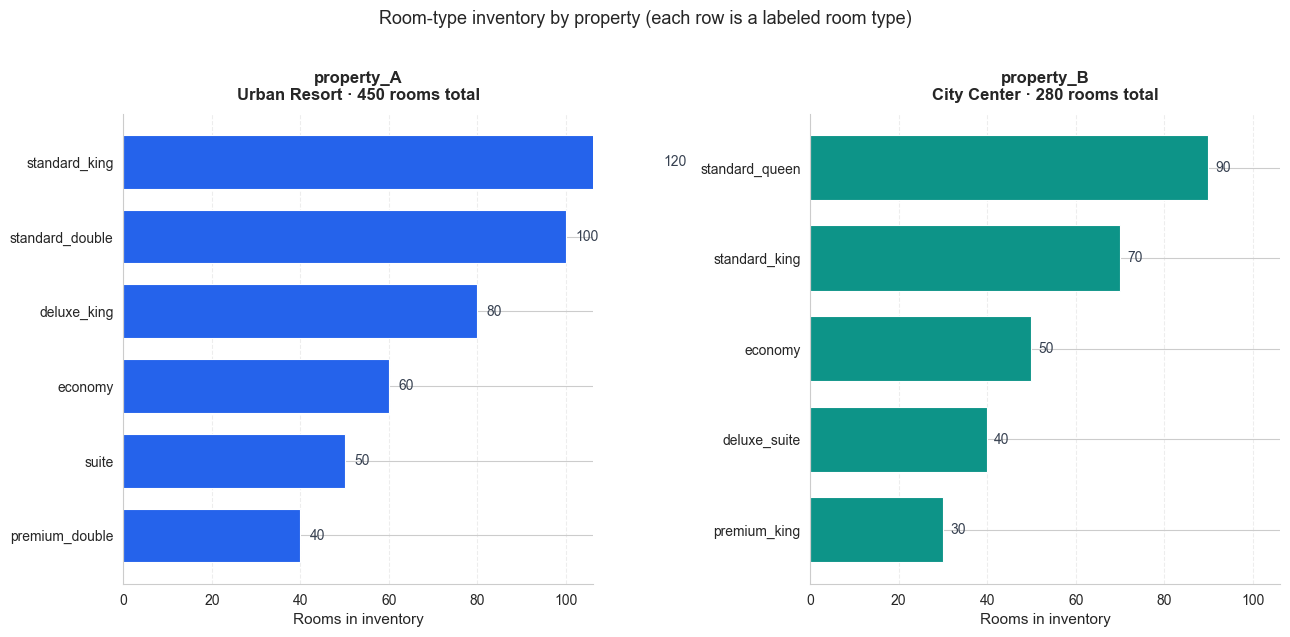

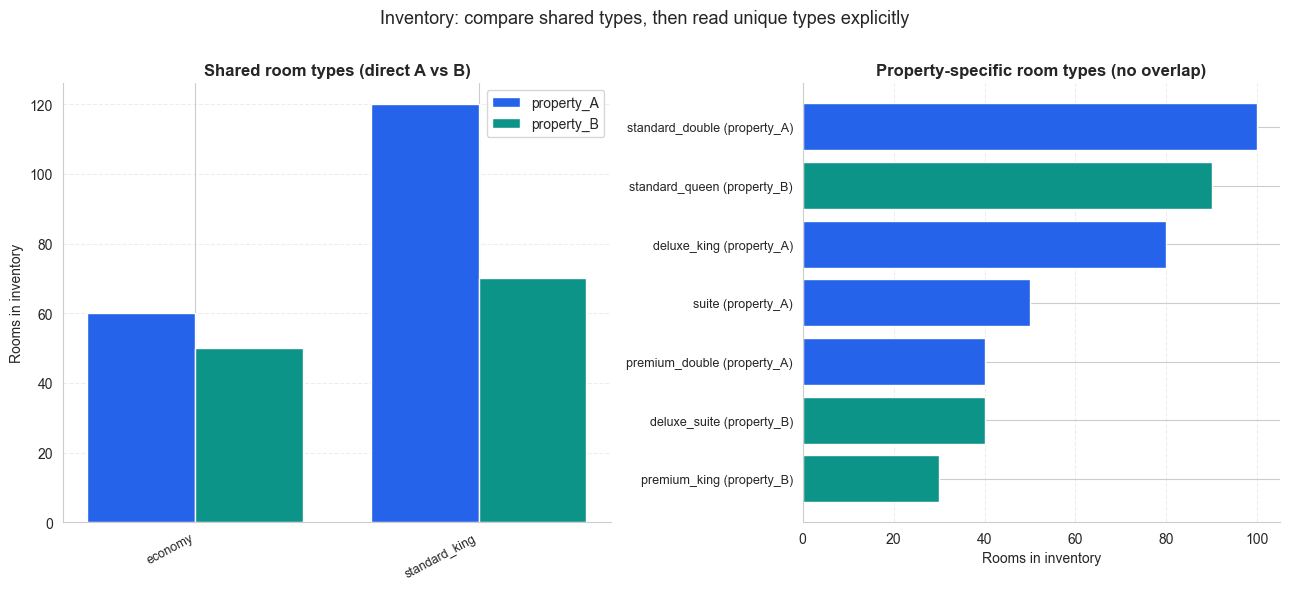

In [214]:
# --- Inventory & location from property_metadata ---
rows = []
for prop_id, info in metadata.items():
    loc = info.get('location_type', 'unknown')
    total = info.get('total_rooms', 0)
    for rt, rt_info in info.get('room_types', {}).items():
        inv = rt_info.get('inventory_count', 0)
        rows.append({
            'property_id': prop_id,
            'location_type': loc,
            'room_type': rt,
            'inventory_count': inv,
            'property_total_rooms': total,
        })

inv_df = pd.DataFrame(rows)
prop_summary = (
    inv_df.groupby('property_id', as_index=False)
          .agg(
              location_type=('location_type', 'first'),
              total_rooms=('property_total_rooms', 'first'),
              n_room_types=('room_type', 'count'),
          )
)
print('Property summary (from metadata):')
display(prop_summary)

prop_colors = {'property_A': '#2563eb', 'property_B': '#0d9488'}
props_sorted = sorted(inv_df['property_id'].unique())
fig1, axes = plt.subplots(1, len(props_sorted), figsize=(13, 6.2), sharex=True)
if len(props_sorted) == 1:
    axes = [axes]
for ax, pid in zip(axes, props_sorted):
    sub = inv_df[inv_df['property_id'] == pid].sort_values('inventory_count', ascending=False)
    loc = sub['location_type'].iloc[0].replace('_', ' ').title()
    tot = int(sub['property_total_rooms'].iloc[0])
    y_pos = np.arange(len(sub))
    vals = sub['inventory_count'].to_numpy()
    ax.barh(y_pos, vals, height=0.72, color=prop_colors.get(pid, '#4b5563'), edgecolor='white', linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sub['room_type'], fontsize=10)
    ax.invert_yaxis()
    xmax = vals.max() * 1.18 if len(vals) else 1
    ax.set_xlim(0, xmax)
    for yi, v in zip(y_pos, vals):
        ax.text(v + xmax * 0.015, yi, f'{int(v)}', va='center', fontsize=10, color='#374151')
    ax.set_xlabel('Rooms in inventory', fontsize=11)
    ax.set_title(f'{pid}\n{loc} · {tot} rooms total', fontsize=12, fontweight='semibold', pad=10)
    ax.grid(axis='x', linestyle='--', alpha=0.35)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig1.suptitle('Room-type inventory by property (each row is a labeled room type)', fontsize=13, y=1.02)
fig1.tight_layout()
plt.show()

all_rt = sorted(inv_df['room_type'].unique())
wide = inv_df.pivot(index='room_type', columns='property_id', values='inventory_count').reindex(all_rt)
have_both = wide.dropna(how='any').index.tolist()
only_a = wide[wide['property_B'].isna() & wide['property_A'].notna()].index.tolist()
only_b = wide[wide['property_A'].isna() & wide['property_B'].notna()].index.tolist()
fig2, axes = plt.subplots(1, 2, figsize=(13, 5.8), gridspec_kw={'width_ratios': [1.15, 1]})
if have_both:
    x = np.arange(len(have_both))
    w = 0.38
    axes[0].bar(x - w / 2, wide.loc[have_both, 'property_A'], width=w, label='property_A', color=prop_colors['property_A'], edgecolor='white')
    axes[0].bar(x + w / 2, wide.loc[have_both, 'property_B'], width=w, label='property_B', color=prop_colors['property_B'], edgecolor='white')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(have_both, rotation=28, ha='right', fontsize=9)
    axes[0].set_ylabel('Rooms in inventory')
    axes[0].set_title('Shared room types (direct A vs B)', fontsize=12, fontweight='semibold')
    axes[0].legend(frameon=True, loc='upper right')
    axes[0].grid(axis='y', linestyle='--', alpha=0.35)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
else:
    axes[0].text(0.5, 0.5, 'No overlapping room types', ha='center', va='center')
    axes[0].axis('off')

parts = only_a + only_b
if parts:
    sub_only = inv_df[inv_df['room_type'].isin(parts)].sort_values('inventory_count', ascending=False)
    yp = np.arange(len(sub_only))
    cols = [prop_colors[p] for p in sub_only['property_id']]
    axes[1].barh(yp, sub_only['inventory_count'], color=cols, edgecolor='white')
    axes[1].set_yticks(yp)
    lab = [f"{r['room_type']} ({r['property_id']})" for _, r in sub_only.iterrows()]
    axes[1].set_yticklabels(lab, fontsize=9)
    axes[1].set_xlabel('Rooms in inventory')
    axes[1].set_title('Property-specific room types (no overlap)', fontsize=12, fontweight='semibold')
    axes[1].invert_yaxis()
    axes[1].grid(axis='x', linestyle='--', alpha=0.35)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
else:
    axes[1].text(0.5, 0.5, 'No property-specific-only types', ha='center', va='center')
    axes[1].axis('off')

fig2.suptitle('Inventory: compare shared types, then read unique types explicitly', fontsize=13, y=1.01)
fig2.tight_layout()
plt.show()

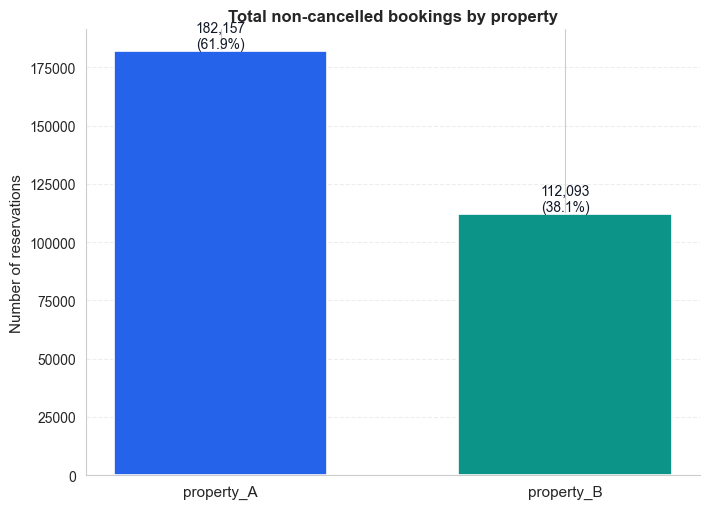

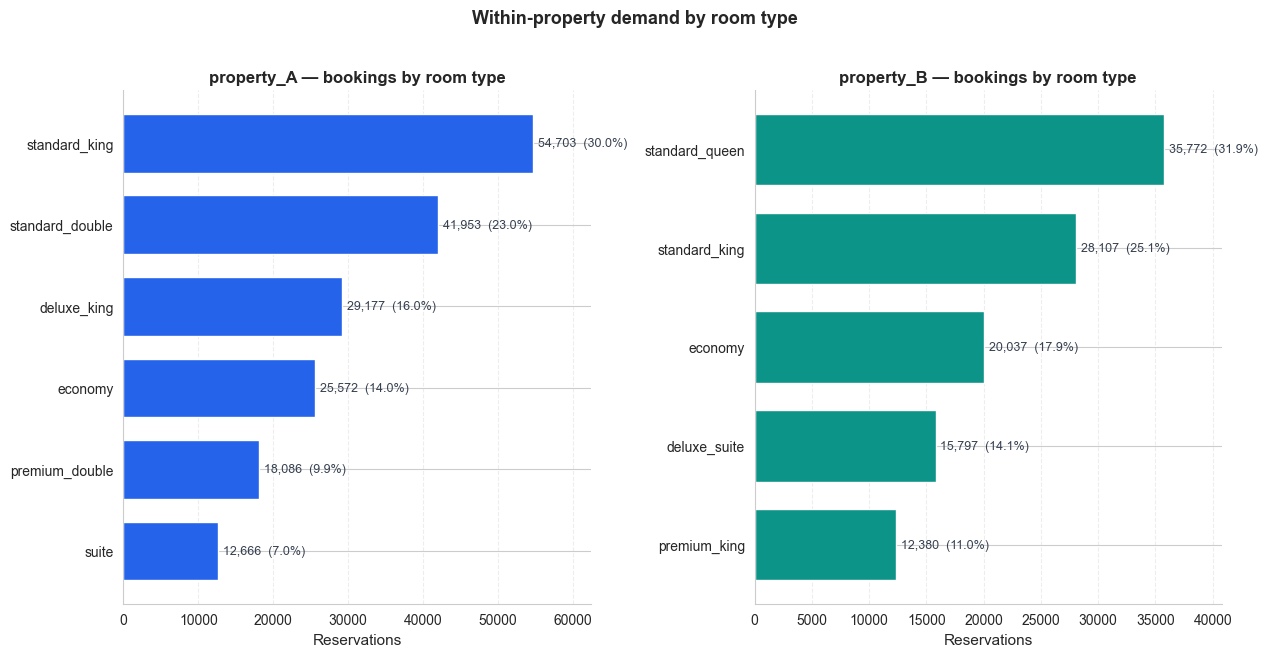

,property_id,room_type,n_bookings,share_within_property
4,property_A,standard_king,54703,0.300307
3,property_A,standard_double,41953,0.230312
0,property_A,deluxe_king,29177,0.160175
1,property_A,economy,25572,0.140384
2,property_A,premium_double,18086,0.099288
5,property_A,suite,12666,0.069533
10,property_B,standard_queen,35772,0.319128
9,property_B,standard_king,28107,0.250747
7,property_B,economy,20037,0.178753
6,property_B,deluxe_suite,15797,0.140928


In [215]:
# --- Reservation mix: property & room type (non-cancelled only) — same property colors as inventory ---
res_active = reservations[reservations['status'] != 'cancelled'].copy()
prop_colors = {'property_A': '#2563eb', 'property_B': '#0d9488'}

mix = (
    res_active.groupby(['property_id', 'room_type'], as_index=False)
              .agg(n_bookings=('reservation_id', 'count'))
)
mix['share_within_property'] = mix.groupby('property_id')['n_bookings'].transform(lambda s: s / s.sum())

prop_totals = res_active.groupby('property_id').size().sort_index()
pct = 100 * prop_totals / prop_totals.sum()

fig, ax = plt.subplots(figsize=(7.2, 5.2))
x = np.arange(len(prop_totals))
bars = ax.bar(
    x,
    prop_totals.values,
    color=[prop_colors[p] for p in prop_totals.index],
    edgecolor='white',
    linewidth=1.2,
    width=0.62,
)
ax.set_xticks(x)
ax.set_xticklabels(list(prop_totals.index), fontsize=11)
ax.set_ylabel('Number of reservations', fontsize=11)
ax.set_title('Total non-cancelled bookings by property', fontsize=12, fontweight='semibold')
for rect, n, p in zip(bars, prop_totals.values, pct.values):
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height(),
        f'{int(n):,}\n({p:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
        color='#111827',
    )
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
plt.show()

props_sorted = sorted(res_active['property_id'].unique())
n_p = len(props_sorted)
fig2, axes2 = plt.subplots(1, n_p, figsize=(6.4 * n_p, 6.4), sharex=False)
if n_p == 1:
    axes2 = [axes2]
for ax, pid in zip(axes2, props_sorted):
    sub = mix[mix['property_id'] == pid].sort_values('n_bookings', ascending=False)
    yp = np.arange(len(sub))
    ax.barh(yp, sub['n_bookings'], height=0.72, color=prop_colors.get(pid, '#6b7280'), edgecolor='white')
    ax.set_yticks(yp)
    ax.set_yticklabels(sub['room_type'], fontsize=10)
    ax.invert_yaxis()
    m = sub['n_bookings'].max()
    ax.set_xlim(0, m * 1.14 if m else 1)
    for yi, v, sh in zip(yp, sub['n_bookings'], sub['share_within_property']):
        ax.text(
            v + m * 0.012,
            yi,
            f'{int(v):,}  ({100 * sh:.1f}%)',
            va='center',
            fontsize=9,
            color='#374151',
        )
    ax.set_xlabel('Reservations', fontsize=11)
    ax.set_title(f'{pid} — bookings by room type', fontsize=12, fontweight='semibold')
    ax.grid(axis='x', linestyle='--', alpha=0.35)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig2.suptitle('Within-property demand by room type', fontsize=13, y=1.02, fontweight='semibold')
fig2.tight_layout()
plt.show()

display(mix.sort_values(['property_id', 'n_bookings'], ascending=[True, False]))

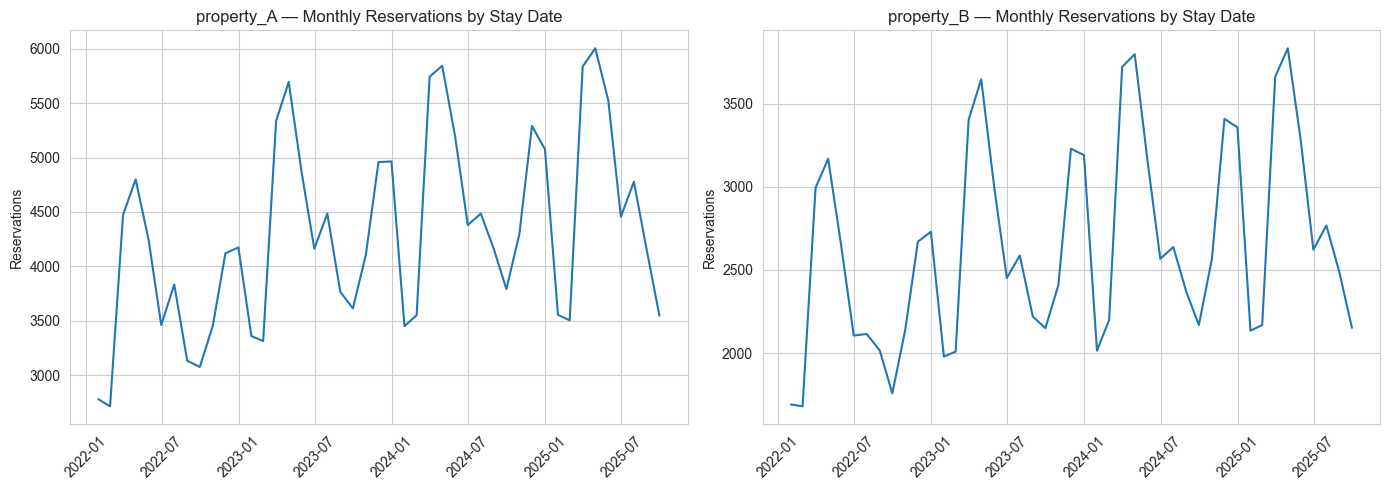

In [216]:
# Monthly reservation volume
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, prop in enumerate(reservations['property_id'].unique()):
    prop_res = reservations[reservations['property_id'] == prop]
    monthly = prop_res.set_index('stay_date').resample('ME').size()
    axes[i].plot(monthly.index, monthly.values)
    axes[i].set_title(f'{prop} — Monthly Reservations by Stay Date')
    axes[i].set_ylabel('Reservations')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

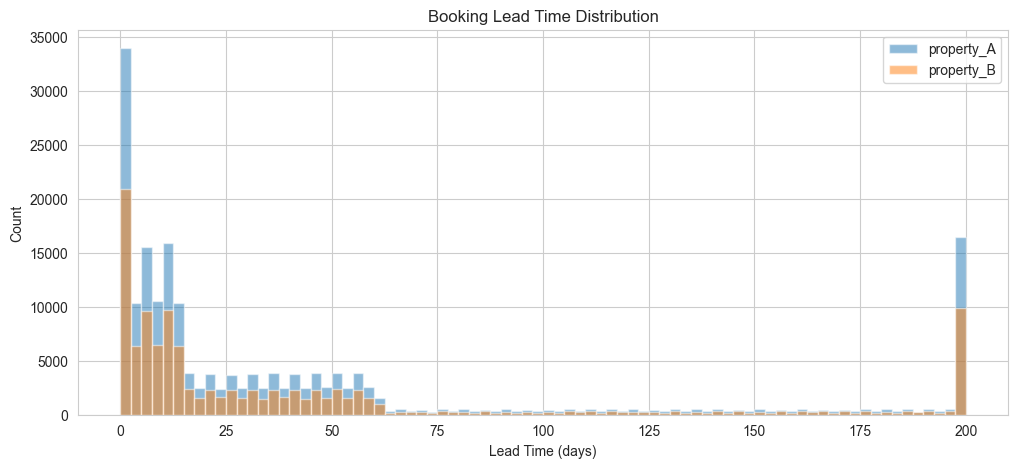

In [217]:
# Lead time distribution
fig, ax = plt.subplots(figsize=(12, 5))
for prop in reservations['property_id'].unique():
    prop_res = reservations[reservations['property_id'] == prop]
    ax.hist(prop_res['lead_time_days'].clip(upper=200), bins=80, alpha=0.5, label=prop)

ax.set_xlabel('Lead Time (days)')
ax.set_ylabel('Count')
ax.set_title('Booking Lead Time Distribution')
ax.legend()
plt.show()

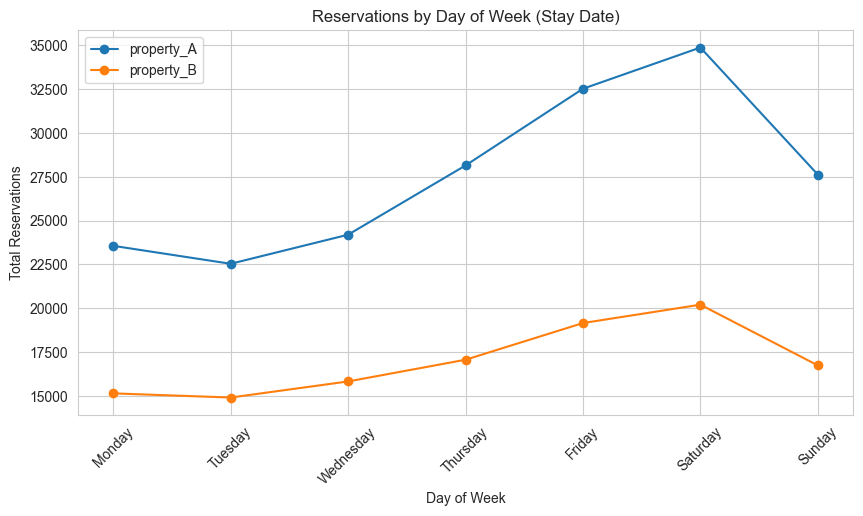

In [218]:
# Day-of-week patterns
reservations['dow'] = reservations['stay_date'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, ax = plt.subplots(figsize=(10, 5))
for prop in reservations['property_id'].unique():
    prop_res = reservations[reservations['property_id'] == prop]
    dow_counts = prop_res.groupby('dow').size().reindex(dow_order)
    ax.plot(dow_order, dow_counts.values, marker='o', label=prop)

ax.set_xlabel('Day of Week')
ax.set_ylabel('Total Reservations')
ax.set_title('Reservations by Day of Week (Stay Date)')
ax.legend()
plt.xticks(rotation=45)
plt.show()

### 2.1 Cancellation behavior by booking lead-time

Cancellation risk often varies strongly with how far in advance a reservation is made. This helps identify whether long-horizon demand is noisier than near-term demand.

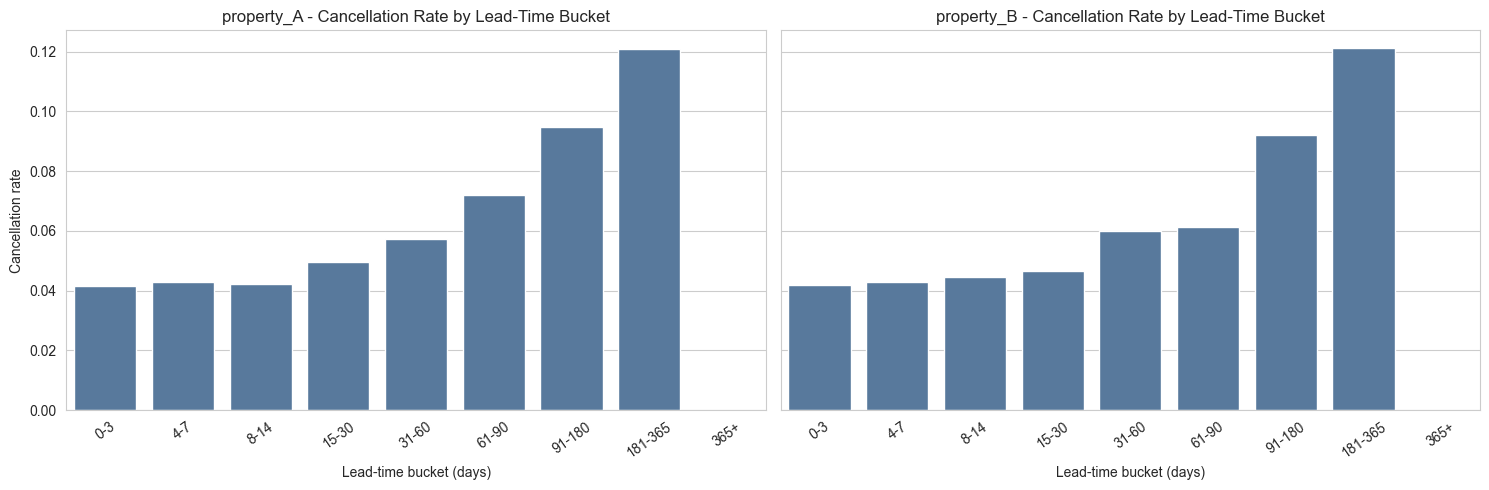

,property_id,lead_bucket,bookings,cancel_rate
0,property_A,0-3,24943,0.041455
1,property_A,4-7,20670,0.043058
2,property_A,8-14,36805,0.042141
3,property_A,15-30,19963,0.049692
4,property_A,31-60,37921,0.057145
5,property_A,61-90,4878,0.072161
6,property_A,91-180,14688,0.094703
7,property_A,181-365,19281,0.120741
8,property_A,365+,0,NaN
9,property_B,0-3,15244,0.041918


In [219]:
# Cancellation rate by lead-time bucket and property
res2 = reservations.copy()
res2['is_cancelled'] = (res2['status'].str.lower() == 'cancelled').astype(int)

bins = [0, 3, 7, 14, 30, 60, 90, 180, 365, np.inf]
labels = ['0-3', '4-7', '8-14', '15-30', '31-60', '61-90', '91-180', '181-365', '365+']
res2['lead_bucket'] = pd.cut(res2['lead_time_days'].clip(lower=0), bins=bins, labels=labels, right=True)

cancel_tbl = (
    res2.groupby(['property_id', 'lead_bucket'], observed=False)
        .agg(bookings=('reservation_id', 'count'), cancel_rate=('is_cancelled', 'mean'))
        .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for i, prop in enumerate(sorted(cancel_tbl['property_id'].dropna().unique())):
    d = cancel_tbl[cancel_tbl['property_id'] == prop]
    sns.barplot(data=d, x='lead_bucket', y='cancel_rate', ax=axes[i], color='#4c78a8')
    axes[i].set_title(f'{prop} - Cancellation Rate by Lead-Time Bucket')
    axes[i].set_xlabel('Lead-time bucket (days)')
    axes[i].set_ylabel('Cancellation rate')
    axes[i].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

display(cancel_tbl.sort_values(['property_id', 'lead_bucket']))

### 2.2 How booking windows shift through the year

This shows whether certain stay months are booked earlier/later, which is useful for curve-shape expectations by season.

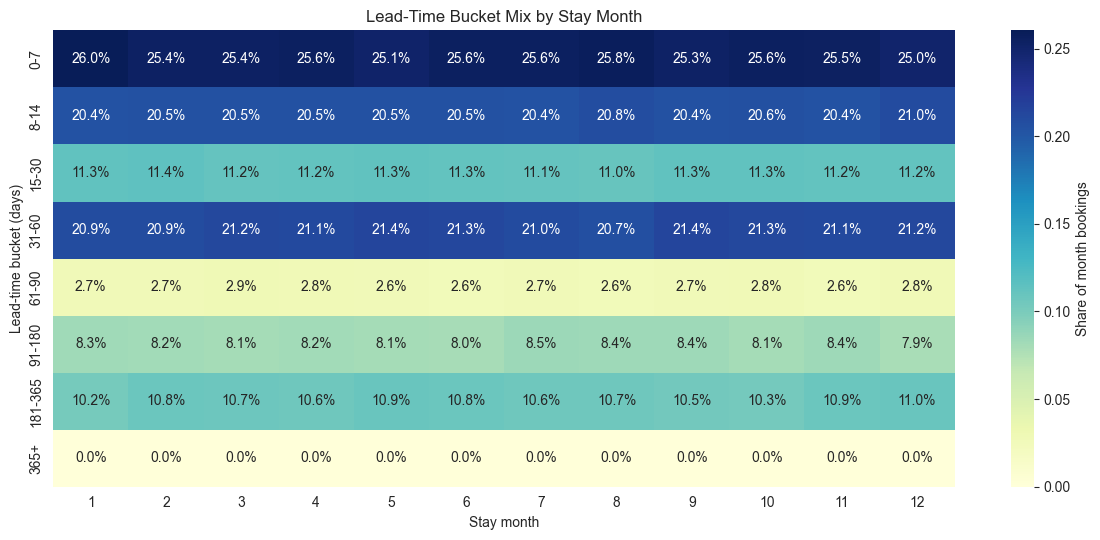

In [220]:
# Monthly composition of lead-time buckets (share-of-bookings heatmap)
res3 = reservations.copy()
res3['stay_month'] = res3['stay_date'].dt.month
res3['lead_bucket'] = pd.cut(
    res3['lead_time_days'].clip(lower=0),
    bins=[0, 7, 14, 30, 60, 90, 180, 365, np.inf],
    labels=['0-7', '8-14', '15-30', '31-60', '61-90', '91-180', '181-365', '365+'],
    right=True,
)

mix = (
    res3.groupby(['stay_month', 'lead_bucket'], observed=False)
        .size()
        .rename('n')
        .reset_index()
)
mix['month_total'] = mix.groupby('stay_month')['n'].transform('sum')
mix['share'] = np.where(mix['month_total'] > 0, mix['n'] / mix['month_total'], 0)

heat = mix.pivot(index='lead_bucket', columns='stay_month', values='share').reindex(
    ['0-7', '8-14', '15-30', '31-60', '61-90', '91-180', '181-365', '365+']
)

plt.figure(figsize=(12, 5.5))
sns.heatmap(heat, annot=True, fmt='.1%', cmap='YlGnBu', cbar_kws={'label': 'Share of month bookings'})
plt.title('Lead-Time Bucket Mix by Stay Month')
plt.xlabel('Stay month')
plt.ylabel('Lead-time bucket (days)')
plt.tight_layout()
plt.show()

### 2.3 Length-of-stay and room-type behavior

Longer stays can alter occupancy dynamics differently by room type and property.

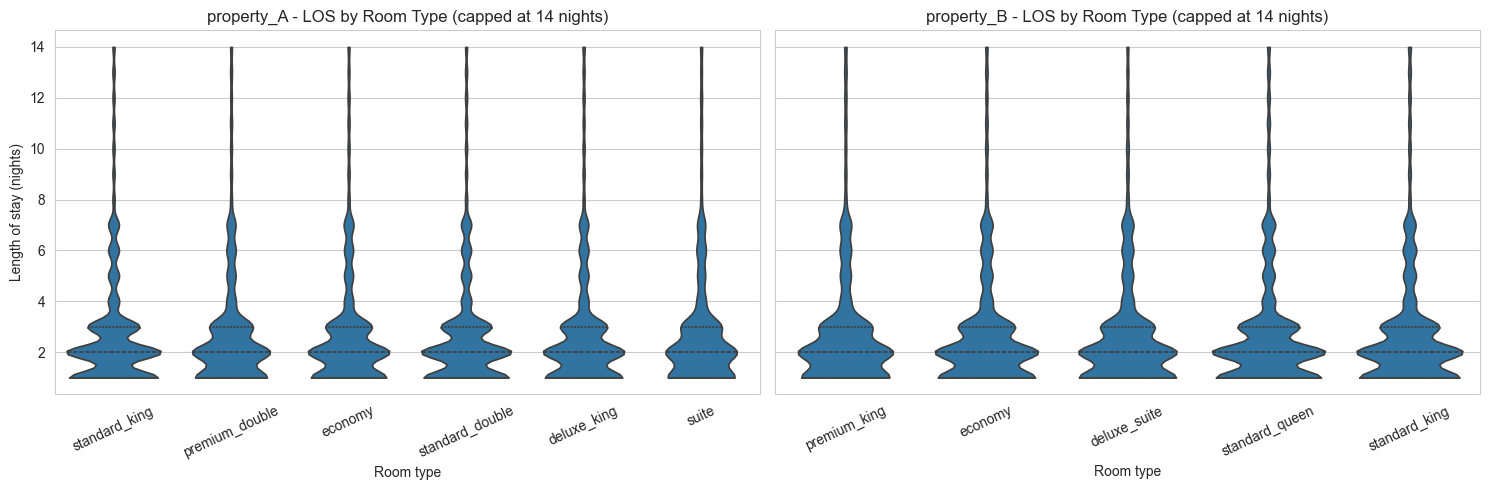

,property_id,room_type,bookings,los_mean,los_median,p_long_stay_5plus
0,property_A,deluxe_king,31025,2.876648,2.0,0.164480
5,property_A,suite,13408,2.873508,2.0,0.163559
1,property_A,economy,27131,2.866573,2.0,0.162434
4,property_A,standard_king,58185,2.850082,2.0,0.161382
2,property_A,premium_double,19191,2.848679,2.0,0.162055
3,property_A,standard_double,44507,2.834138,2.0,0.158357
9,property_B,standard_king,29847,2.877576,2.0,0.166147
10,property_B,standard_queen,38027,2.862598,2.0,0.162016
8,property_B,premium_king,13062,2.849717,2.0,0.162839
7,property_B,economy,21375,2.835602,2.0,0.161544


In [221]:
# Length-of-stay (LOS) patterns by property and room_type
res4 = reservations.copy()
res4['los_nights'] = (res4['checkout_date'] - res4['stay_date']).dt.days.clip(lower=1)
res4['los_nights_clip'] = res4['los_nights'].clip(upper=14)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for i, prop in enumerate(sorted(res4['property_id'].dropna().unique())):
    d = res4[res4['property_id'] == prop]
    sns.violinplot(data=d, x='room_type', y='los_nights_clip', ax=axes[i], inner='quartile', cut=0)
    axes[i].set_title(f'{prop} - LOS by Room Type (capped at 14 nights)')
    axes[i].set_xlabel('Room type')
    axes[i].set_ylabel('Length of stay (nights)')
    axes[i].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

los_summary = (
    res4.groupby(['property_id', 'room_type'], observed=False)
        .agg(
            bookings=('reservation_id', 'count'),
            los_mean=('los_nights', 'mean'),
            los_median=('los_nights', 'median'),
            p_long_stay_5plus=('los_nights', lambda s: (s >= 5).mean()),
        )
        .reset_index()
)
display(los_summary.sort_values(['property_id', 'los_mean'], ascending=[True, False]))

## 2b. Additional Seasonality Patterns (Stay-Date)

The baseline only uses **month** and **day-of-week**. Here we look for richer (still leakage-safe) calendar structure:

- **Week-of-year / day-of-year**: captures within-season peaks and shoulder periods.
- **Month × day-of-week interactions**: weekends behave differently in different months.
- **Holiday windows**: demand often spikes around major holidays (with lead/lag effects).

All plots below use **stay_date** (not booking_date), because we’re trying to understand *what kind of night* is being forecast.

In [222]:
# Add stay-date calendar fields for seasonality EDA
res = reservations.copy()
res['stay_year'] = res['stay_date'].dt.year
res['stay_month'] = res['stay_date'].dt.month
res['stay_doy'] = res['stay_date'].dt.dayofyear
res['stay_woy'] = res['stay_date'].dt.isocalendar().week.astype(int)
res['stay_is_weekend'] = res['stay_date'].dt.dayofweek.isin([5, 6]).astype(int)

print('Stay years:', sorted(res['stay_year'].unique()))
res[['stay_date','stay_year','stay_month','stay_woy','stay_doy','stay_is_weekend']].head()

Stay years: [np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


,stay_date,stay_year,stay_month,stay_woy,stay_doy,stay_is_weekend
0,2022-01-01,2022,1,52,1,1
1,2022-01-01,2022,1,52,1,1
2,2022-01-01,2022,1,52,1,1
3,2022-01-01,2022,1,52,1,1
4,2022-01-01,2022,1,52,1,1


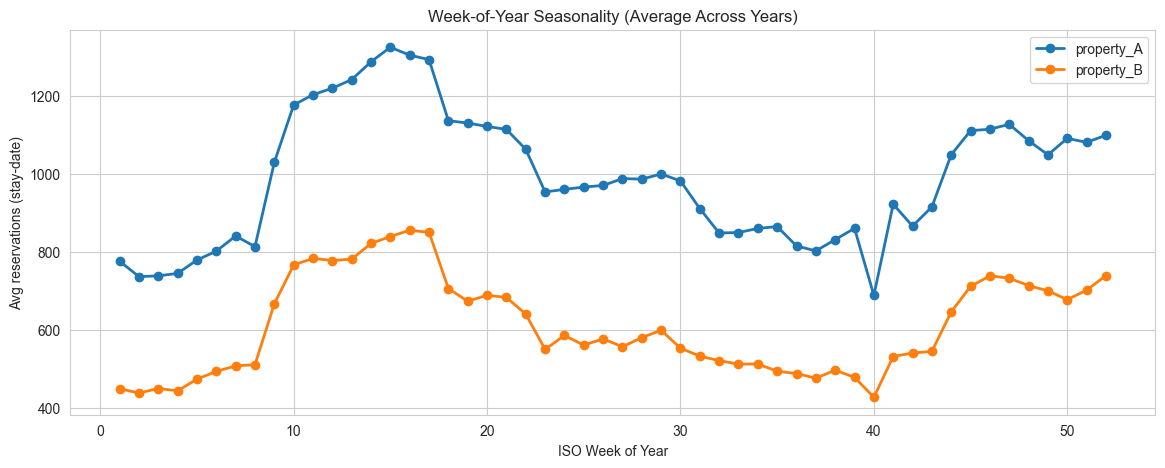

In [223]:
# Weekly seasonality: average reservations per stay-week (by property)
# This is a "shape" plot: it highlights peak/slow weeks.

weekly = (
    res.groupby(['property_id', 'stay_year', 'stay_woy'])
       .size()
       .reset_index(name='reservations')
)

fig, ax = plt.subplots(figsize=(14, 5))
for prop in weekly['property_id'].unique():
    tmp = weekly[weekly['property_id'] == prop]
    # Average across years so we see a stable seasonal curve
    mean_by_woy = tmp.groupby('stay_woy')['reservations'].mean()
    ax.plot(mean_by_woy.index, mean_by_woy.values, marker='o', linewidth=2, label=prop)

ax.set_xlabel('ISO Week of Year')
ax.set_ylabel('Avg reservations (stay-date)')
ax.set_title('Week-of-Year Seasonality (Average Across Years)')
ax.legend()
plt.show()

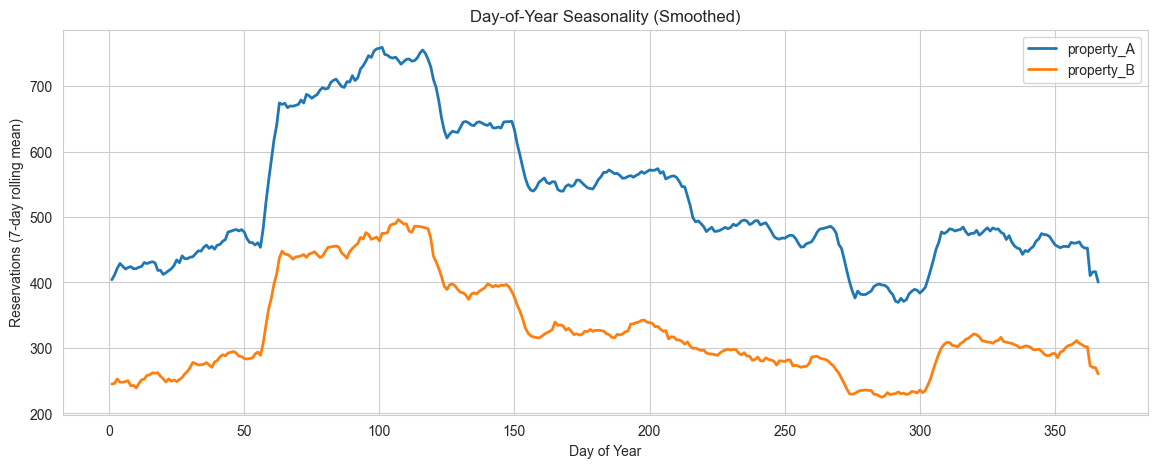

In [224]:
# Day-of-year seasonality: smooth curve (by property)
# We use a rolling mean to reduce noise.

by_doy = (
    res.groupby(['property_id', 'stay_doy'])
       .size()
       .reset_index(name='reservations')
)

fig, ax = plt.subplots(figsize=(14, 5))
for prop in by_doy['property_id'].unique():
    tmp = by_doy[by_doy['property_id'] == prop].sort_values('stay_doy')
    tmp['reservations_smooth'] = tmp['reservations'].rolling(7, center=True, min_periods=1).mean()
    ax.plot(tmp['stay_doy'], tmp['reservations_smooth'], linewidth=2, label=prop)

ax.set_xlabel('Day of Year')
ax.set_ylabel('Reservations (7-day rolling mean)')
ax.set_title('Day-of-Year Seasonality (Smoothed)')
ax.legend()
plt.show()

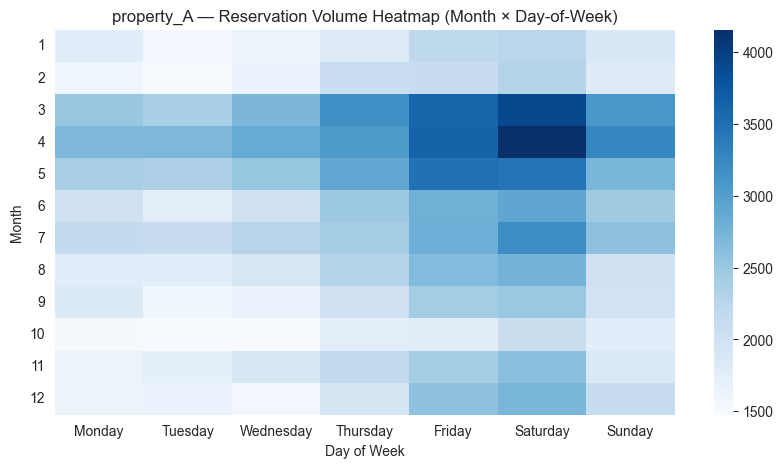

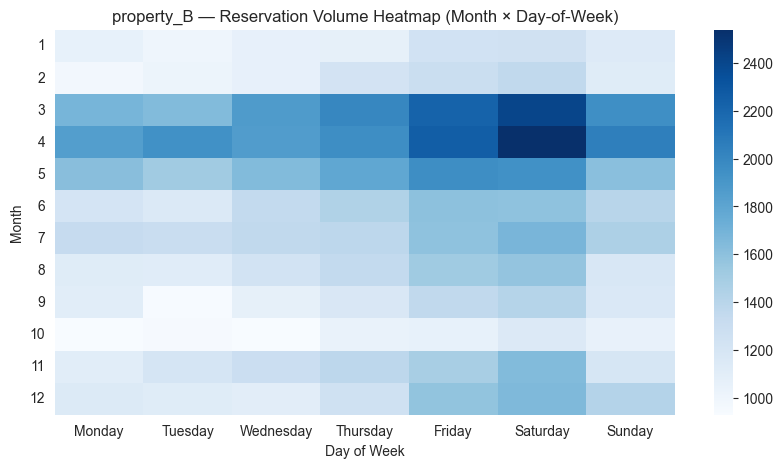

In [225]:
# Month × Day-of-Week interaction: heatmap of stay-date reservation volume
# Useful because "Friday in July" can behave differently than "Friday in January".

heat = (
    res.assign(stay_dow=res['stay_date'].dt.day_name())
      .groupby(['property_id', 'stay_month', 'stay_dow'])
      .size()
      .reset_index(name='reservations')
)

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

for prop in heat['property_id'].unique():
    pivot = (heat[heat['property_id'] == prop]
             .pivot(index='stay_month', columns='stay_dow', values='reservations')
             .reindex(columns=dow_order)
             .fillna(0))

    plt.figure(figsize=(10, 5))
    sns.heatmap(pivot, cmap='Blues')
    plt.title(f'{prop} — Reservation Volume Heatmap (Month × Day-of-Week)')
    plt.xlabel('Day of Week')
    plt.ylabel('Month')
    plt.yticks(rotation=0)
    plt.show()

### 2b.1 Build an analysis table with engineered calendar features

To directly evaluate the engineered seasonality/holiday features, we create a stay-date level table from `daily_occupancy.csv` and derive the same feature family used in modeling.

In [226]:
# Stay-date level analysis table aligned with engineered calendar features
occ_day = pd.read_csv(DATA_DIR / 'daily_occupancy.csv', parse_dates=['date'])
occ_day = (
    occ_day.groupby('date', as_index=False)
           .agg(occupancy_pct=('occupancy_pct', 'mean'))
           .rename(columns={'date': 'stay_date'})
           .sort_values('stay_date')
)

# Core calendar features
occ_day['year'] = occ_day['stay_date'].dt.year
occ_day['month'] = occ_day['stay_date'].dt.month
occ_day['dow'] = occ_day['stay_date'].dt.dayofweek
occ_day['week_of_year'] = occ_day['stay_date'].dt.isocalendar().week.astype(int)
occ_day['day_of_year'] = occ_day['stay_date'].dt.dayofyear
occ_day['quarter'] = occ_day['stay_date'].dt.quarter
occ_day['is_weekend'] = occ_day['dow'].isin([5, 6]).astype(int)
min_date = occ_day['stay_date'].min()
occ_day['days_since_data_start'] = (occ_day['stay_date'] - min_date).dt.days

# Cyclical encodings
occ_day['sin_month'] = np.sin(2 * np.pi * (occ_day['month'] / 12.0))
occ_day['cos_month'] = np.cos(2 * np.pi * (occ_day['month'] / 12.0))
occ_day['sin_dow'] = np.sin(2 * np.pi * (occ_day['dow'] / 7.0))
occ_day['cos_dow'] = np.cos(2 * np.pi * (occ_day['dow'] / 7.0))
occ_day['sin_doy'] = np.sin(2 * np.pi * (occ_day['day_of_year'] / 366.0))
occ_day['cos_doy'] = np.cos(2 * np.pi * (occ_day['day_of_year'] / 366.0))

# Holiday proximity features
major_holidays = pd.to_datetime([
    '2022-01-01','2022-07-04','2022-11-24','2022-12-25',
    '2023-01-01','2023-07-04','2023-11-23','2023-12-25',
    '2024-01-01','2024-07-04','2024-11-28','2024-12-25',
    '2025-01-01','2025-07-04','2025-11-27','2025-12-25',
])

def holiday_min_abs_days(stay: pd.Timestamp) -> float:
    return float(np.min(np.abs((major_holidays - stay).days)))

occ_day['holiday_min_abs_days'] = occ_day['stay_date'].apply(holiday_min_abs_days)
occ_day['is_holiday_window_3d'] = (occ_day['holiday_min_abs_days'] <= 3).astype(int)

print(f"Stay-date rows: {len(occ_day):,}")
print("Columns added:", [
    'year','week_of_year','day_of_year','quarter','is_weekend','days_since_data_start',
    'sin_month','cos_month','sin_dow','cos_dow','sin_doy','cos_doy',
    'holiday_min_abs_days','is_holiday_window_3d'
])
occ_day.head()

Stay-date rows: 1,368
Columns added: ['year', 'week_of_year', 'day_of_year', 'quarter', 'is_weekend', 'days_since_data_start', 'sin_month', 'cos_month', 'sin_dow', 'cos_dow', 'sin_doy', 'cos_doy', 'holiday_min_abs_days', 'is_holiday_window_3d']


,stay_date,occupancy_pct,year,month,dow,week_of_year,day_of_year,quarter,is_weekend,days_since_data_start,sin_month,cos_month,sin_dow,cos_dow,sin_doy,cos_doy,holiday_min_abs_days,is_holiday_window_3d
0,2022-01-01,0.204964,2022,1,5,52,1,1,1,0,0.5,0.866025,-0.974928,-0.222521,0.017166,0.999853,0.0,1
1,2022-01-02,0.312245,2022,1,6,52,2,1,1,1,0.5,0.866025,-0.781831,0.623490,0.034328,0.999411,1.0,1
2,2022-01-03,0.318718,2022,1,0,1,3,1,0,2,0.5,0.866025,0.000000,1.000000,0.051479,0.998674,2.0,1
3,2022-01-04,0.354391,2022,1,1,1,4,1,0,3,0.5,0.866025,0.781831,0.623490,0.068615,0.997643,3.0,1
4,2022-01-05,0.379500,2022,1,2,1,5,1,0,4,0.5,0.866025,0.974928,-0.222521,0.085731,0.996318,4.0,0


### 2b.2 Global trend + quarter/weekend effects

This directly inspects `days_since_data_start`, `quarter`, and `is_weekend` to test whether demand drifts over time and whether weekend effects vary by season.

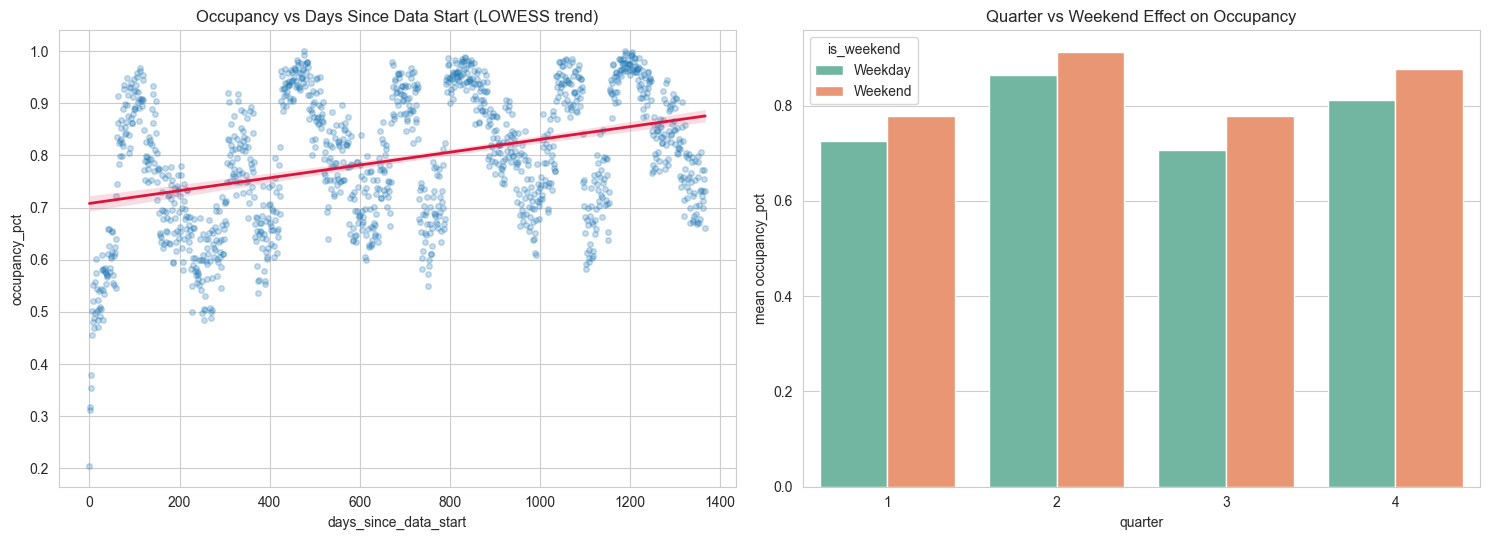

In [227]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# A) Occupancy vs global clock with smooth fit
sns.regplot(
    data=occ_day,
    x='days_since_data_start', y='occupancy_pct',
    scatter_kws={'alpha': 0.25, 's': 16},
    line_kws={'color': 'crimson', 'linewidth': 2},
    ax=axes[0]
)
axes[0].set_title('Occupancy vs Days Since Data Start (LOWESS trend)')
axes[0].set_xlabel('days_since_data_start')
axes[0].set_ylabel('occupancy_pct')

# B) Quarter x weekend interaction
qwk = (
    occ_day.groupby(['quarter', 'is_weekend'], as_index=False)
           .agg(occupancy_pct=('occupancy_pct', 'mean'))
)
sns.barplot(
    data=qwk,
    x='quarter',
    y='occupancy_pct',
    hue='is_weekend',
    hue_order=[0, 1],
    ax=axes[1],
    palette=['#66c2a5', '#fc8d62'],
)
axes[1].set_title('Quarter vs Weekend Effect on Occupancy')
axes[1].set_xlabel('quarter')
axes[1].set_ylabel('mean occupancy_pct')
h, _ = axes[1].get_legend_handles_labels()
axes[1].legend(h, ['Weekday', 'Weekend'], title='is_weekend')

plt.tight_layout()
plt.show()

### 2b.3 Intra-year structure: week-of-year heatmap

A year-by-week heatmap reveals repeatable seasonal peaks/troughs and helps validate `week_of_year` and `day_of_year` feature utility.

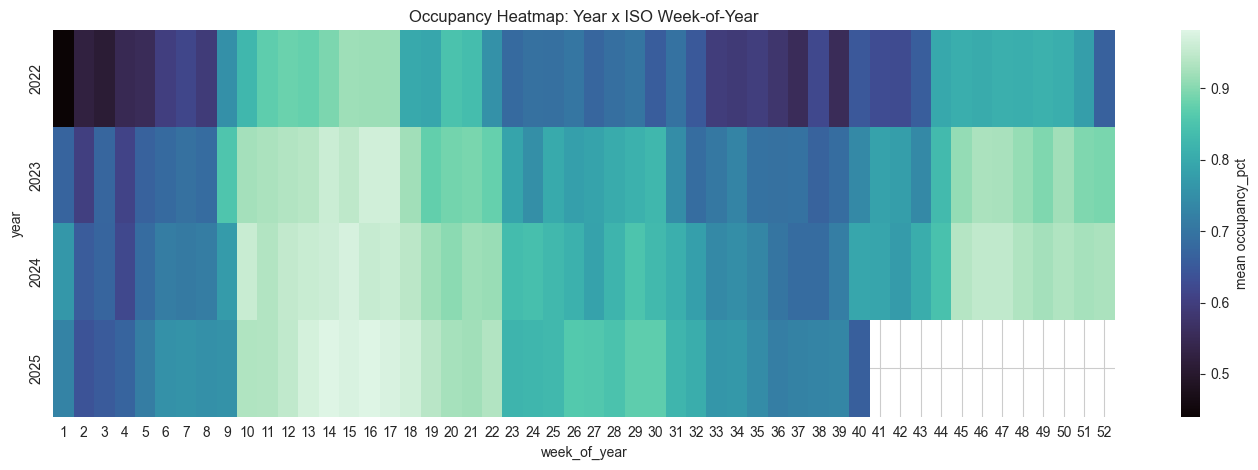

In [228]:
woy_pivot = (
    occ_day.groupby(['year', 'week_of_year'], as_index=False)
           .agg(occupancy_pct=('occupancy_pct', 'mean'))
           .pivot(index='year', columns='week_of_year', values='occupancy_pct')
           .sort_index()
)

plt.figure(figsize=(14, 4.8))
sns.heatmap(woy_pivot, cmap='mako', cbar_kws={'label': 'mean occupancy_pct'})
plt.title('Occupancy Heatmap: Year x ISO Week-of-Year')
plt.xlabel('week_of_year')
plt.ylabel('year')
plt.tight_layout()
plt.show()

### 2b.4 Holiday proximity event-study

This targets `holiday_min_abs_days` / `is_holiday_window_3d` explicitly and checks whether occupancy systematically lifts (or dips) near major holidays.

C:\Users\benya\AppData\Local\Temp\ipykernel_7032\253022110.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hwin, x='is_holiday_window_3d', y='occupancy_pct', ax=axes[1], palette=['#4c78a8', '#f58518'])


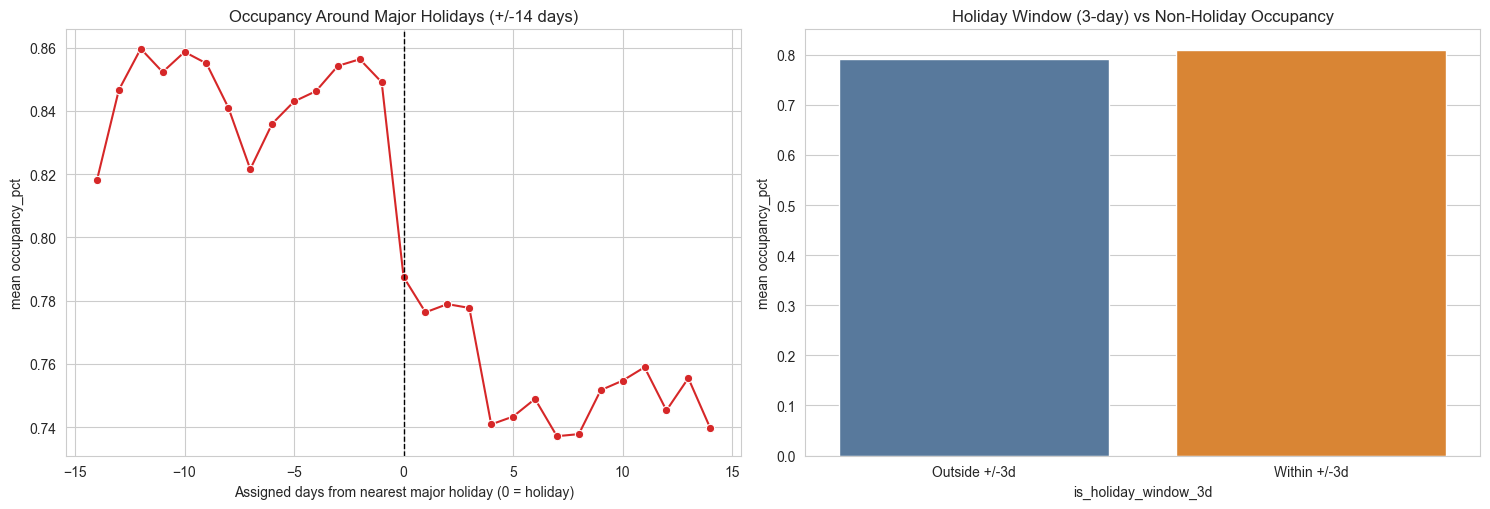

,is_holiday_window_3d,occupancy_pct,n_days
0,0,0.790553,1273
1,1,0.810087,95


Correlation with occupancy_pct (engineered seasonality/holiday features):


,corr_with_occupancy_pct
days_since_data_start,0.373778
sin_doy,0.361162
sin_month,0.313876
holiday_min_abs_days,0.219569
is_weekend,0.207634
day_of_year,0.111656
quarter,0.088098
week_of_year,0.086997
is_holiday_window_3d,0.038301
cos_dow,-0.026165


In [230]:
# Signed distance to nearest major holiday for event-study style profile
def signed_days_to_nearest_holiday(stay: pd.Timestamp) -> int:
    deltas = (stay - major_holidays).days
    i = int(np.argmin(np.abs(deltas)))
    return int(deltas[i])

occ_day['holiday_signed_days'] = occ_day['stay_date'].apply(signed_days_to_nearest_holiday)

window = 14
evt = (
    occ_day[occ_day['holiday_signed_days'].between(-window, window)]
    .groupby('holiday_signed_days', as_index=False)
    .agg(occupancy_pct=('occupancy_pct', 'mean'), n_days=('occupancy_pct', 'size'))
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

sns.lineplot(data=evt, x='holiday_signed_days', y='occupancy_pct', marker='o', ax=axes[0], color='#d62728')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Occupancy Around Major Holidays (+/-14 days)')
axes[0].set_xlabel('Assigned days from nearest major holiday (0 = holiday)')
axes[0].set_ylabel('mean occupancy_pct')

hwin = occ_day.groupby('is_holiday_window_3d', as_index=False).agg(
    occupancy_pct=('occupancy_pct', 'mean'),
    n_days=('occupancy_pct', 'size')
)
sns.barplot(data=hwin, x='is_holiday_window_3d', y='occupancy_pct', ax=axes[1], palette=['#4c78a8', '#f58518'])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Outside +/-3d', 'Within +/-3d'])
axes[1].set_title('Holiday Window (3-day) vs Non-Holiday Occupancy')
axes[1].set_xlabel('is_holiday_window_3d')
axes[1].set_ylabel('mean occupancy_pct')

plt.tight_layout()
plt.show()

display(hwin)

# Quick numeric signal check for engineered seasonality/holiday features
signal_cols = [
    'week_of_year', 'day_of_year', 'quarter', 'is_weekend', 'days_since_data_start',
    'sin_month', 'cos_month', 'sin_dow', 'cos_dow', 'sin_doy', 'cos_doy',
    'holiday_min_abs_days', 'is_holiday_window_3d'
]
corr_sig = occ_day[['occupancy_pct'] + signal_cols].corr(numeric_only=True)['occupancy_pct'].drop('occupancy_pct').sort_values(ascending=False)
print('Correlation with occupancy_pct (engineered seasonality/holiday features):')
display(corr_sig.to_frame('corr_with_occupancy_pct'))

## 3. Building a Booking Curve

This is the core concept. Let's build actual booking curves for a sample of stay dates.

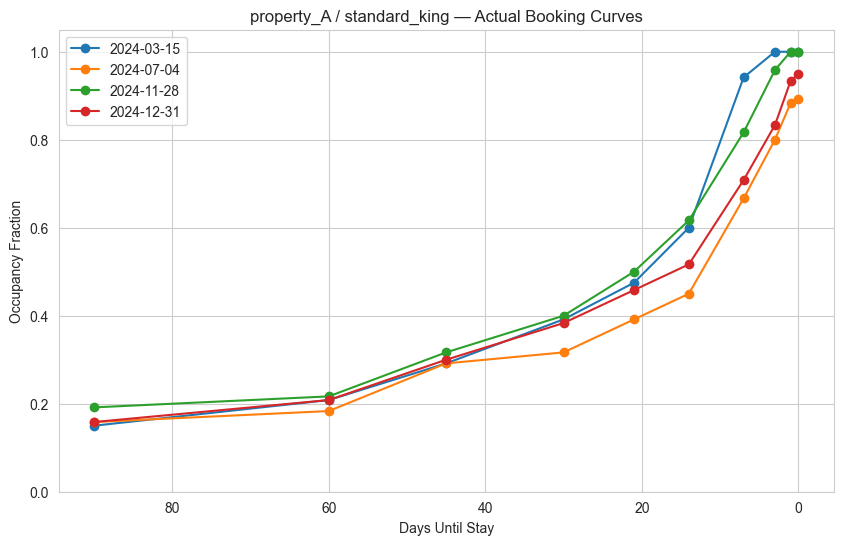

In [231]:
CHECKPOINTS = [90, 60, 45, 30, 21, 14, 7, 3, 1, 0]

def compute_booking_curve(res_df, property_id, room_type, target_night, total_rooms):
    """Compute the actual booking curve for a specific night.

    A reservation contributes to every night it covers: a guest checking in
    June 13 and checking out June 16 occupies a room on nights June 13, 14,
    and 15. So for target_night = June 14, that reservation counts if
    stay_date <= June 14 AND checkout_date > June 14.
    """
    mask = (
        (res_df['property_id'] == property_id)
        & (res_df['room_type'] == room_type)
        & (res_df['stay_date'] <= target_night)
        & (res_df['checkout_date'] > target_night)
        & (res_df['status'] != 'cancelled')
    )
    bookings = res_df[mask]

    curve = {}
    for cp in CHECKPOINTS:
        cutoff = target_night - pd.Timedelta(days=cp)
        booked = (bookings['booking_date'] <= cutoff).sum()
        curve[cp] = min(booked / total_rooms, 1.0)

    return curve


# Example: plot curves for a few dates
sample_dates = pd.to_datetime(['2024-03-15', '2024-07-04', '2024-11-28', '2024-12-31'])
prop = 'property_A'
rt = 'standard_king'
total = metadata[prop]['room_types'][rt]['inventory_count']

fig, ax = plt.subplots(figsize=(10, 6))
for sd in sample_dates:
    curve = compute_booking_curve(reservations, prop, rt, sd, total)
    x = sorted(curve.keys(), reverse=True)  # 90 → 0
    y = [curve[cp] for cp in x]
    ax.plot(x, y, marker='o', label=sd.strftime('%Y-%m-%d'))

ax.set_xlabel('Days Until Stay')
ax.set_ylabel('Occupancy Fraction')
ax.set_title(f'{prop} / {rt} — Actual Booking Curves')
ax.invert_xaxis()
ax.legend()
ax.set_ylim(0, 1.05)
plt.show()

## 4. Seasonality and Trends

Explore how final occupancy and curve shapes vary by season.

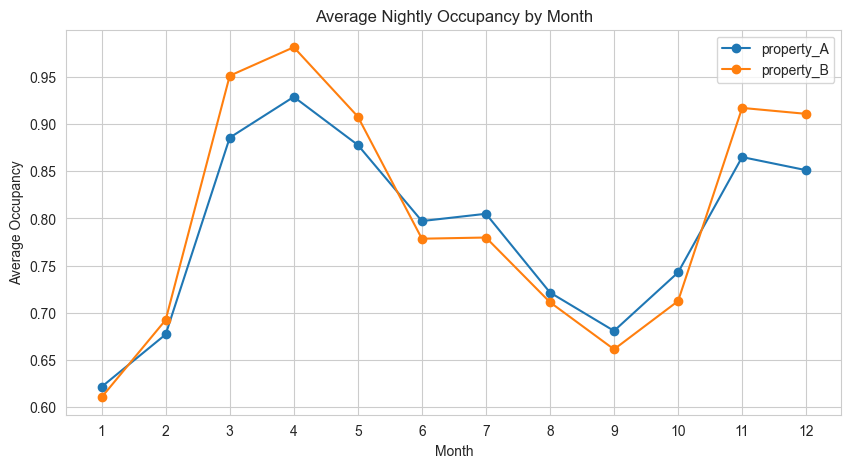

In [232]:
# Compute nightly occupancy across all nights
# Each reservation covers [stay_date, checkout_date) — every night in that range
active = reservations[reservations['status'] != 'cancelled'].copy()

# Use daily_occupancy.csv which already accounts for multi-night stays
occ = pd.read_csv(DATA_DIR / 'daily_occupancy.csv', parse_dates=['date'])
occ['month'] = occ['date'].dt.month

# Plot monthly average occupancy
fig, ax = plt.subplots(figsize=(10, 5))
for prop in occ['property_id'].unique():
    prop_data = occ[occ['property_id'] == prop]
    monthly_occ = prop_data.groupby('month')['occupancy_pct'].mean()
    ax.plot(monthly_occ.index, monthly_occ.values, marker='o', label=prop)

ax.set_xlabel('Month')
ax.set_ylabel('Average Occupancy')
ax.set_title('Average Nightly Occupancy by Month')
ax.set_xticks(range(1, 13))
ax.legend()
plt.show()

## 5. Event Impact (Stretch)

How do local events affect booking patterns?

In [233]:
events.duration_days.mean()

np.float64(2.308075772681954)

Event categories: {'conferences': 453, 'festivals': 192, 'sports': 125, 'concerts': 125, 'community': 108}

Days with major events (rank >= 85): 187
Average attendance: 3,089
Median predicted accommodation spend: $31,796


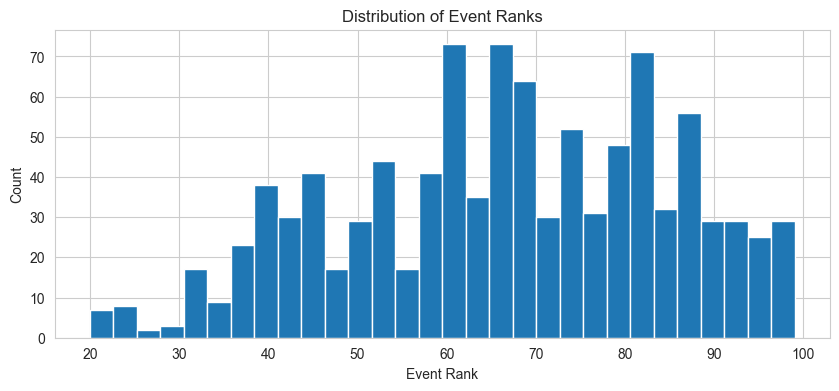

In [234]:
print(f"Event categories: {events['category'].value_counts().to_dict()}")
print(f"\nDays with major events (rank >= 85): {(events['rank'] >= 85).sum()}")
print(f"Average attendance: {events['attendance'].mean():,.0f}")
print(f"Median predicted accommodation spend: ${events['predicted_accommodation_spend'].median():,.0f}")

# Distribution of event ranks
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(events['rank'], bins=30)
ax.set_xlabel('Event Rank')
ax.set_ylabel('Count')
ax.set_title('Distribution of Event Ranks')
plt.show()

### 5.1 Event features vs occupancy EDA (daily_event_impacts-based)

Rows in merged daily EDA table: 1,368
Days with at least one event: 726


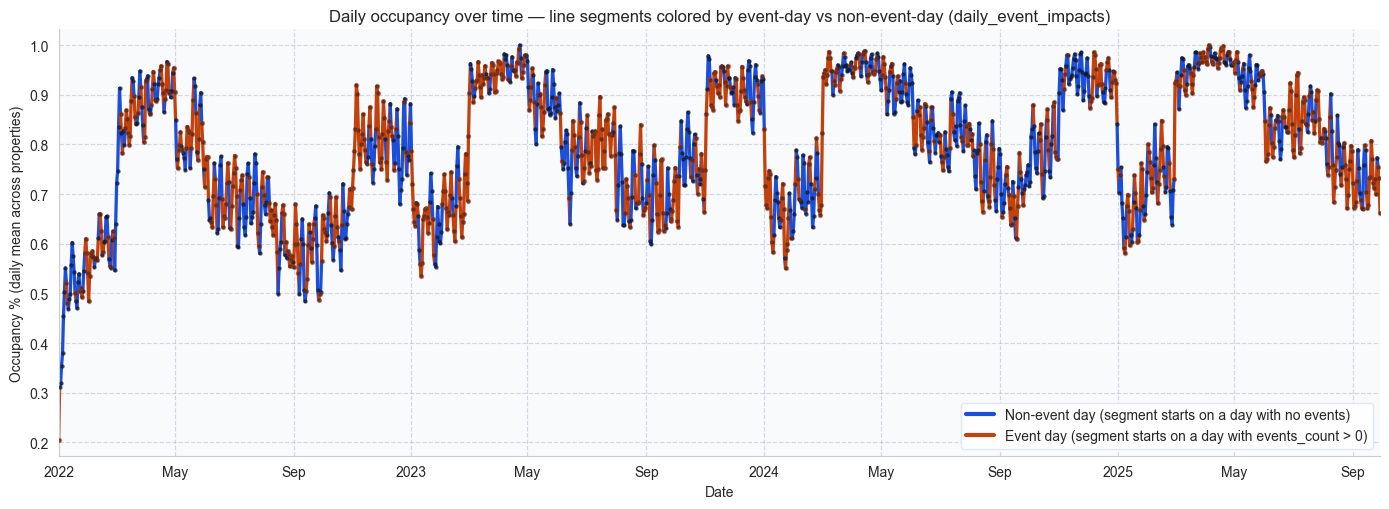

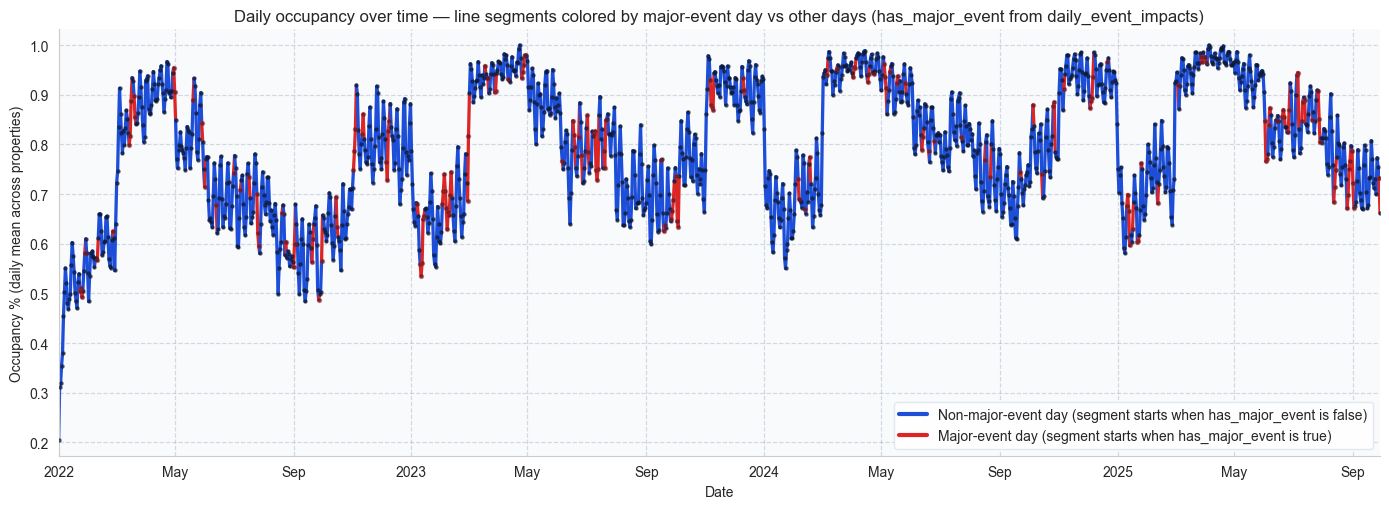


Correlation with occupancy_pct (daily mean across properties):
events_count              0.001
spend_total              -0.005
impact_lagging_total     -0.007
impact_leading_total     -0.010
impact_event_day_total   -0.013
rank_max                 -0.020
total_attendance         -0.021
rank_mean                -0.027
Name: occupancy_pct, dtype: float64


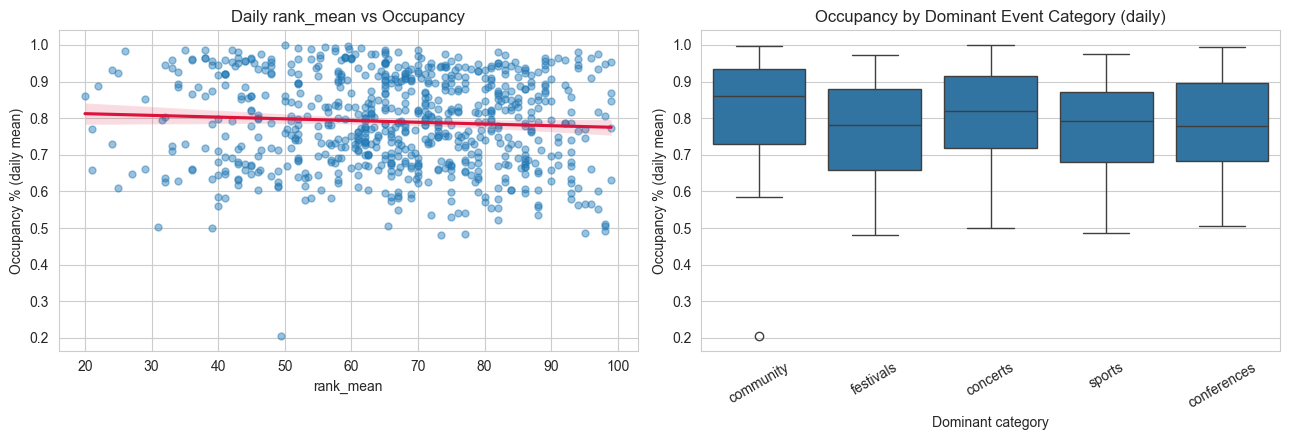

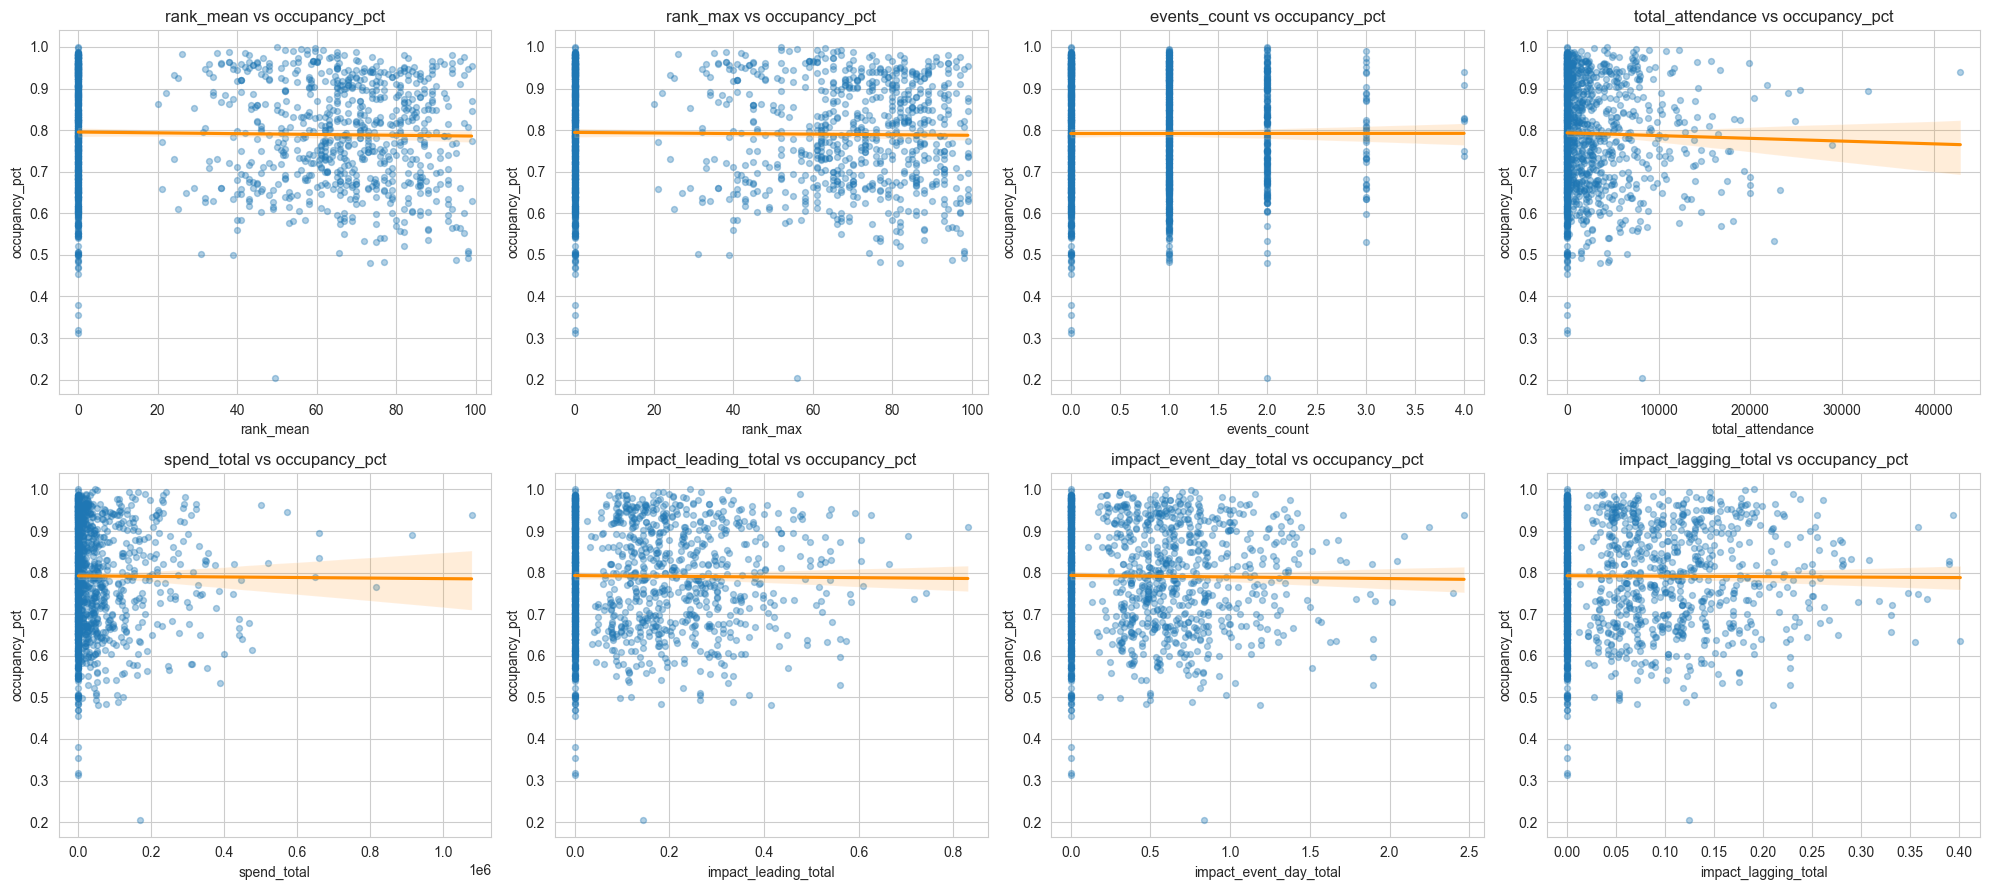

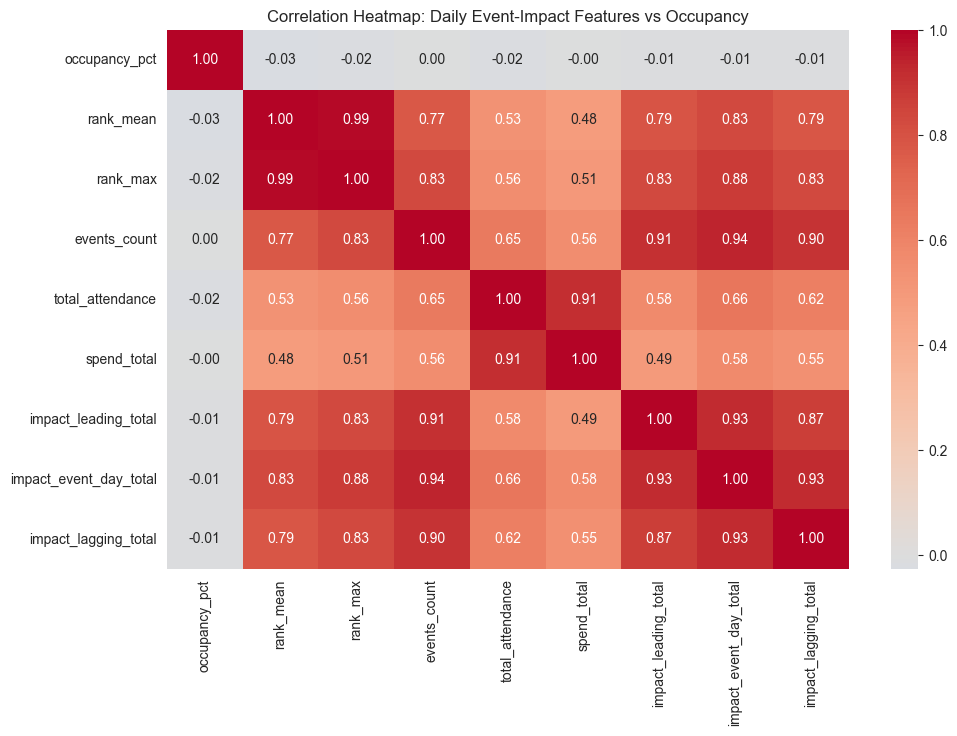

In [235]:
### Goal: understand how aggregated daily event signals relate to daily occupancy

occ = pd.read_csv(DATA_DIR / 'daily_occupancy.csv', parse_dates=['date'])
occ_daily = (
    occ.groupby('date', as_index=False)
       .agg(
           occupancy_pct=('occupancy_pct', 'mean'),
           occupancy_median=('occupancy_pct', 'median'),
           properties_reporting=('property_id', 'nunique')
       )
)

# Use pre-aggregated daily event impacts
de = pd.read_csv(DATA_DIR / 'daily_event_impacts.csv', parse_dates=['date'])

# Keep only expected columns if present and normalize names for plotting
rename_map = {
    'total_accommodation_spend': 'spend_total',
    'max_rank': 'rank_max',
    'avg_rank': 'rank_mean',
}
de = de.rename(columns=rename_map)

# Optional category context from events.csv (for category-level occupancy view)
category_per_day = (
    events.groupby('date')['category']
          .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0])
          .reset_index(name='dominant_category')
)

eda = (
    occ_daily
    .merge(de.rename(columns={'date': 'date'}), on='date', how='left')
    .merge(category_per_day, on='date', how='left')
)

num_cols = [
    'events_count', 'rank_mean', 'rank_max',
    'total_attendance', 'spend_total',
    'impact_leading_total', 'impact_event_day_total', 'impact_lagging_total'
]
existing_num_cols = [c for c in num_cols if c in eda.columns]

eda[existing_num_cols] = eda[existing_num_cols].fillna(0)
eda['dominant_category'] = eda['dominant_category'].fillna('none')

print(f"Rows in merged daily EDA table: {len(eda):,}")
if 'events_count' in eda.columns:
    print(f"Days with at least one event: {(eda['events_count'] > 0).sum():,}")

# --- Time series: occupancy vs time, line color by event / no-event day ---
# Uses daily_event_impacts: a day is an "event day" when events_count > 0 (fallback: has_major_event)

ts = eda.sort_values('date').reset_index(drop=True)
if 'events_count' in ts.columns:
    ts['has_event'] = ts['events_count'].fillna(0) > 0
elif 'has_major_event' in ts.columns:
    ts['has_event'] = pd.to_numeric(ts['has_major_event'], errors='coerce').fillna(0) > 0
else:
    ts['has_event'] = False

xnum = mdates.date2num(ts['date'].to_numpy())
yvals = ts['occupancy_pct'].to_numpy(dtype=float)
he = ts['has_event'].to_numpy()

COLOR_CALM = '#1d4ed8'      # blue — baseline days
COLOR_EVENT = '#c2410c'     # warm rust — event signal present
FACE = '#f8fafc'

fig, ax = plt.subplots(figsize=(14, 5.2))
ax.set_facecolor(FACE)

if len(ts) >= 2:
    pts = np.column_stack([xnum, yvals])
    segments = np.stack([pts[:-1], pts[1:]], axis=1)
    # Color each segment by the starting day: "does this day have event activity?"
    seg_colors = np.where(he[:-1], COLOR_EVENT, COLOR_CALM)
    lc = LineCollection(
        segments,
        colors=seg_colors,
        linewidths=2.35,
        capstyle='round',
        joinstyle='round',
        antialiased=True,
        zorder=2,
    )
    ax.add_collection(lc)
    ypad = 0.04 * (np.nanmax(yvals) - np.nanmin(yvals) or 1.0)
    ax.set_xlim(xnum.min(), xnum.max())
    ax.set_ylim(np.nanmin(yvals) - ypad, np.nanmax(yvals) + ypad)
else:
    ax.plot(ts['date'], yvals, color=COLOR_CALM, linewidth=2)

# Overlay point markers for all days to show individual observations
ax.plot(ts['date'], yvals, marker='o', markersize=2.2, linestyle='None', color='#0f172a', alpha=0.6, zorder=3)

# Light markers on event days (helps when the line is dense)
ax.scatter(
    xnum[he],
    yvals[he],
    s=16,
    c=COLOR_EVENT,
    alpha=0.35,
    linewidths=0,
    zorder=3,
)

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.set_xlabel('Date')
ax.set_ylabel('Occupancy % (daily mean across properties)')
ax.set_title('Daily occupancy over time — line segments colored by event-day vs non-event-day (daily_event_impacts)')
ax.grid(True, alpha=0.38, linestyle='--', linewidth=0.85, color='#94a3b8')
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)

legend_elems = [
    Line2D([0], [0], color=COLOR_CALM, lw=3, label='Non-event day (segment starts on a day with no events)'),
    Line2D([0], [0], color=COLOR_EVENT, lw=3, label='Event day (segment starts on a day with events_count > 0)'),
]
ax.legend(handles=legend_elems, loc='lower right', frameon=True, framealpha=0.96, edgecolor='#e2e8f0')

plt.tight_layout()
plt.show()

# --- Same layout: occupancy vs time, but only major-event days highlighted (has_major_event) ---
if 'has_major_event' in ts.columns:
    hm = pd.to_numeric(ts['has_major_event'], errors='coerce').fillna(0).to_numpy() > 0
else:
    hm = np.zeros(len(ts), dtype=bool)

COLOR_MAJOR = '#dc2626'  # red — segment starts on a major-event day

fig, ax = plt.subplots(figsize=(14, 5.2))
ax.set_facecolor(FACE)

if len(ts) >= 2:
    pts = np.column_stack([xnum, yvals])
    segments = np.stack([pts[:-1], pts[1:]], axis=1)
    seg_colors_major = np.where(hm[:-1], COLOR_MAJOR, COLOR_CALM)
    lc_maj = LineCollection(
        segments,
        colors=seg_colors_major,
        linewidths=2.35,
        capstyle='round',
        joinstyle='round',
        antialiased=True,
        zorder=2,
    )
    ax.add_collection(lc_maj)
    ypad = 0.04 * (np.nanmax(yvals) - np.nanmin(yvals) or 1.0)
    ax.set_xlim(xnum.min(), xnum.max())
    ax.set_ylim(np.nanmin(yvals) - ypad, np.nanmax(yvals) + ypad)
else:
    ax.plot(ts['date'], yvals, color=COLOR_CALM, linewidth=2)

# Overlay point markers for all days to show individual observations
ax.plot(ts['date'], yvals, marker='o', markersize=2.2, linestyle='None', color='#0f172a', alpha=0.6, zorder=3)

ax.scatter(
    xnum[hm],
    yvals[hm],
    s=16,
    c=COLOR_MAJOR,
    alpha=0.35,
    linewidths=0,
    zorder=3,
)

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.set_xlabel('Date')
ax.set_ylabel('Occupancy % (daily mean across properties)')
ax.set_title(
    'Daily occupancy over time — line segments colored by major-event day vs other days (has_major_event from daily_event_impacts)'
)
ax.grid(True, alpha=0.38, linestyle='--', linewidth=0.85, color='#94a3b8')
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)

legend_elems_major = [
    Line2D([0], [0], color=COLOR_CALM, lw=3, label='Non-major-event day (segment starts when has_major_event is false)'),
    Line2D([0], [0], color=COLOR_MAJOR, lw=3, label='Major-event day (segment starts when has_major_event is true)'),
]
ax.legend(handles=legend_elems_major, loc='lower right', frameon=True, framealpha=0.96, edgecolor='#e2e8f0')

plt.tight_layout()
plt.show()

# 1) Correlation summary with occupancy
corr = (
    eda[['occupancy_pct'] + existing_num_cols]
    .corr(numeric_only=True)['occupancy_pct']
    .drop('occupancy_pct')
    .sort_values(ascending=False)
)
print('\nCorrelation with occupancy_pct (daily mean across properties):')
print(corr.round(3))

# 2) Event rank relationship with occupancy + category distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

rank_x = 'rank_mean' if 'rank_mean' in eda.columns else ('rank_max' if 'rank_max' in eda.columns else None)
if rank_x is not None:
    rank_data = eda[eda['events_count'] > 0] if 'events_count' in eda.columns else eda
    sns.regplot(
        data=rank_data,
        x=rank_x, y='occupancy_pct',
        scatter_kws={'alpha': 0.45, 's': 25},
        line_kws={'color': 'crimson'},
        ax=axes[0]
    )
    axes[0].set_title(f'Daily {rank_x} vs Occupancy')
    axes[0].set_xlabel(rank_x)
else:
    axes[0].text(0.5, 0.5, 'No rank column found', ha='center', va='center')
    axes[0].set_title('Rank vs Occupancy')
axes[0].set_ylabel('Occupancy % (daily mean)')

sns.boxplot(
    data=eda[eda['dominant_category'] != 'none'],
    x='dominant_category', y='occupancy_pct',
    ax=axes[1]
)
axes[1].set_title('Occupancy by Dominant Event Category (daily)')
axes[1].set_xlabel('Dominant category')
axes[1].set_ylabel('Occupancy % (daily mean)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# 3) Multi-feature relationship panels
plot_features = [
    c for c in [
        'rank_mean', 'rank_max', 'events_count', 'total_attendance', 'spend_total',
        'impact_leading_total', 'impact_event_day_total', 'impact_lagging_total'
    ] if c in eda.columns
]

n = len(plot_features)
if n > 0:
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, feature in zip(axes, plot_features):
        sns.regplot(
            data=eda,
            x=feature,
            y='occupancy_pct',
            scatter_kws={'alpha': 0.35, 's': 18},
            line_kws={'color': 'darkorange'},
            ax=ax
        )
        ax.set_title(f'{feature} vs occupancy_pct')

    for ax in axes[n:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# 4) Correlation heatmap for quick signal scan
heatmap_cols = ['occupancy_pct'] + plot_features
if len(heatmap_cols) > 1:
    plt.figure(figsize=(11, 7))
    sns.heatmap(eda[heatmap_cols].corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap: Daily Event-Impact Features vs Occupancy')
    plt.show()

### 5.2 Event mix and intensity by category

Understand which categories drive event volume vs impact (attendance and accommodation spend).

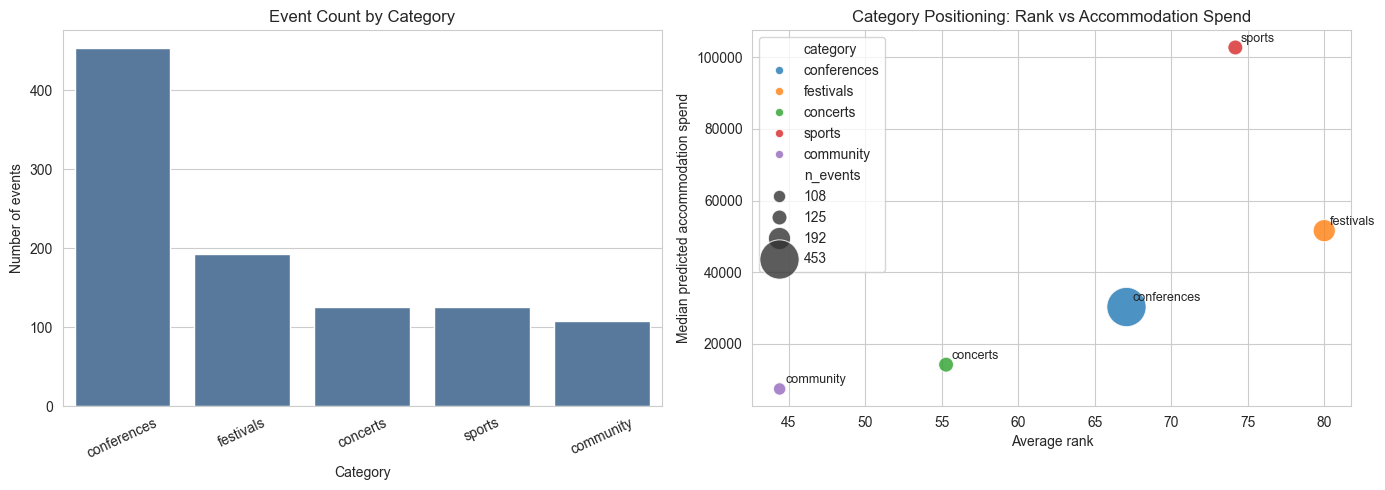

,category,n_events,rank_mean,attendance_median,spend_median,duration_mean
2,conferences,453,67.066225,1720.0,30317.0,3.357616
3,festivals,192,79.984375,2718.0,51628.0,2.270833
1,concerts,125,55.280000,772.0,14231.0,1.000000
4,sports,125,74.176000,4662.0,102745.0,1.000000
0,community,108,44.407407,356.0,7453.5,1.000000


In [236]:
evt_cat = (
    events.groupby('category', as_index=False)
          .agg(
              n_events=('event_id', 'count'),
              rank_mean=('rank', 'mean'),
              attendance_median=('attendance', 'median'),
              spend_median=('predicted_accommodation_spend', 'median'),
              duration_mean=('duration_days', 'mean'),
          )
          .sort_values('n_events', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=evt_cat, x='category', y='n_events', ax=axes[0], color='#4c78a8')
axes[0].set_title('Event Count by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of events')
axes[0].tick_params(axis='x', rotation=25)

sns.scatterplot(
    data=evt_cat,
    x='rank_mean',
    y='spend_median',
    size='n_events',
    hue='category',
    sizes=(80, 800),
    alpha=0.8,
    ax=axes[1],
)
for _, r in evt_cat.iterrows():
    axes[1].annotate(r['category'], (r['rank_mean'], r['spend_median']), xytext=(4, 4), textcoords='offset points', fontsize=9)
axes[1].set_title('Category Positioning: Rank vs Accommodation Spend')
axes[1].set_xlabel('Average rank')
axes[1].set_ylabel('Median predicted accommodation spend')

plt.tight_layout()
plt.show()
display(evt_cat)

### 5.3 Event calendar density through time

This shows when event pressure is clustered and whether there are seasonal waves in event activity.

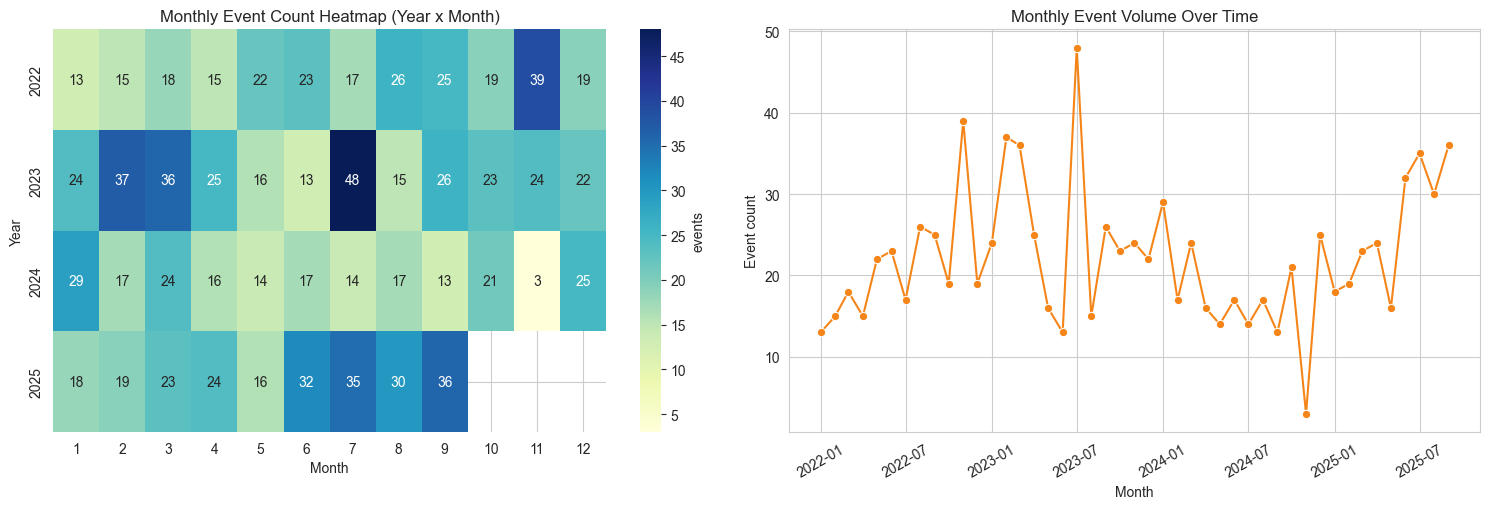

In [237]:
evt_month = (
    events.assign(year=events['date'].dt.year, month=events['date'].dt.month)
          .groupby(['year', 'month'], as_index=False)
          .agg(
              n_events=('event_id', 'count'),
              total_attendance=('attendance', 'sum'),
          )
)

pivot_events = evt_month.pivot(index='year', columns='month', values='n_events').sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
sns.heatmap(pivot_events, cmap='YlGnBu', annot=True, fmt='.0f', ax=axes[0], cbar_kws={'label': 'events'})
axes[0].set_title('Monthly Event Count Heatmap (Year x Month)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Year')

evt_month['ym'] = pd.to_datetime(evt_month[['year', 'month']].assign(day=1))
sns.lineplot(data=evt_month.sort_values('ym'), x='ym', y='n_events', marker='o', ax=axes[1], color='#f58518')
axes[1].set_title('Monthly Event Volume Over Time')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Event count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 5.4 Daily impact decomposition (`daily_event_impacts`)

Break down total event pressure into leading / event-day / lagging components and inspect how concentrated impact is.

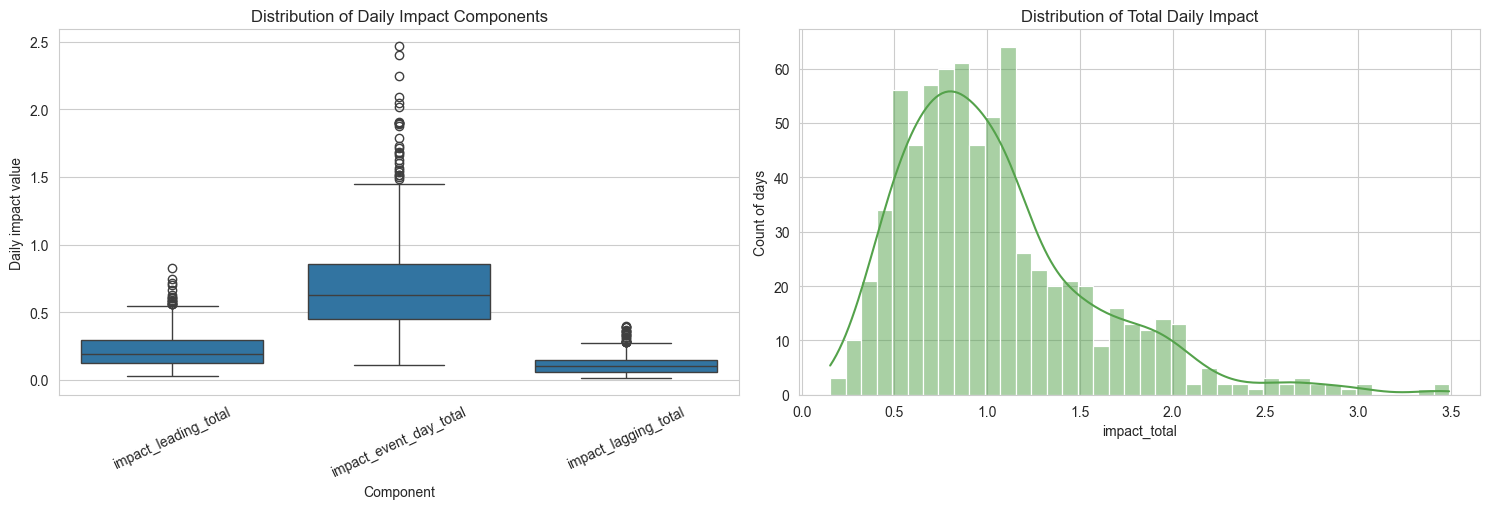

,count,mean,std,min,50%,75%,90%,95%,99%,max
impact_leading_total,726.0,0.226068,0.129231,0.0264,0.19250,0.295500,0.39800,0.490800,0.605225,0.8304
impact_event_day_total,726.0,0.702049,0.365535,0.1065,0.62545,0.856775,1.20100,1.376125,1.896400,2.4679
impact_lagging_total,726.0,0.114648,0.068955,0.0124,0.10180,0.146800,0.20925,0.250000,0.353200,0.4011
impact_total,726.0,1.042765,0.534338,0.1531,0.92680,1.259300,1.78275,2.044550,2.858325,3.4904


In [238]:
de = daily_events.copy().sort_values('date')
impact_cols = ['impact_leading_total', 'impact_event_day_total', 'impact_lagging_total']
for c in impact_cols:
    if c in de.columns:
        de[c] = pd.to_numeric(de[c], errors='coerce').fillna(0)

de['impact_total'] = de[[c for c in impact_cols if c in de.columns]].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

melted = de.melt(id_vars='date', value_vars=[c for c in impact_cols if c in de.columns], var_name='impact_component', value_name='value')
sns.boxplot(data=melted, x='impact_component', y='value', ax=axes[0])
axes[0].set_title('Distribution of Daily Impact Components')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Daily impact value')
axes[0].tick_params(axis='x', rotation=25)

sns.histplot(de['impact_total'], bins=40, kde=True, ax=axes[1], color='#54a24b')
axes[1].set_title('Distribution of Total Daily Impact')
axes[1].set_xlabel('impact_total')
axes[1].set_ylabel('Count of days')

plt.tight_layout()
plt.show()

impact_summary = de[[c for c in impact_cols + ['impact_total'] if c in de.columns]].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T
display(impact_summary)

### 5.5 Major-event profile and concentration

Compare event-day metrics on major-event days vs non-major-event days and inspect Pareto-style concentration of event spend.

,has_major_event,events_count,total_attendance,max_rank,avg_rank,total_accommodation_spend
0,0,1.0,2162.5,66.0,63.00,40261.5
1,1,1.0,3228.0,90.0,86.25,52040.5


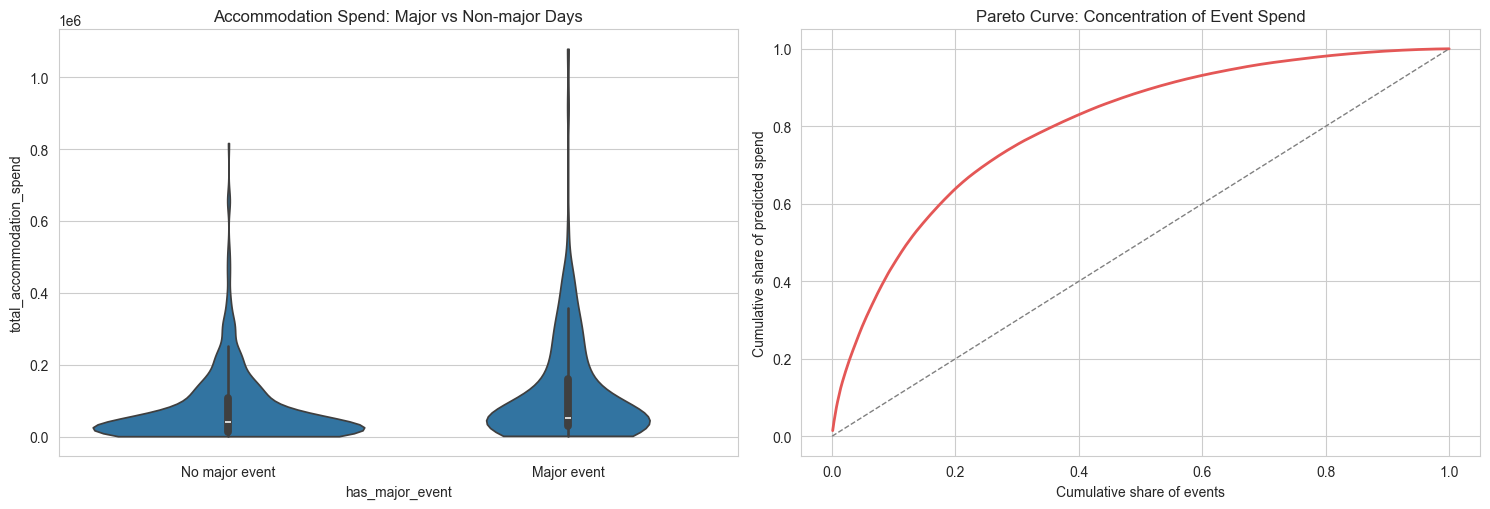

In [239]:
de2 = daily_events.copy()
if 'has_major_event' in de2.columns:
    de2['has_major_event'] = pd.to_numeric(de2['has_major_event'], errors='coerce').fillna(0).astype(int)

compare_cols = [c for c in ['events_count', 'total_attendance', 'max_rank', 'avg_rank', 'total_accommodation_spend'] if c in de2.columns]
major_profile = (
    de2.groupby('has_major_event', as_index=False)[compare_cols]
       .median(numeric_only=True)
)
display(major_profile)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

if 'total_accommodation_spend' in de2.columns:
    sns.violinplot(data=de2, x='has_major_event', y='total_accommodation_spend', ax=axes[0], cut=0)
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(['No major event', 'Major event'])
    axes[0].set_title('Accommodation Spend: Major vs Non-major Days')
    axes[0].set_xlabel('has_major_event')
    axes[0].set_ylabel('total_accommodation_spend')

if 'predicted_accommodation_spend' in events.columns:
    ev_spend = events[['event_id', 'predicted_accommodation_spend']].dropna().sort_values('predicted_accommodation_spend', ascending=False)
    ev_spend['cum_share_events'] = np.arange(1, len(ev_spend) + 1) / len(ev_spend)
    ev_spend['cum_share_spend'] = ev_spend['predicted_accommodation_spend'].cumsum() / ev_spend['predicted_accommodation_spend'].sum()
    axes[1].plot(ev_spend['cum_share_events'], ev_spend['cum_share_spend'], color='#e45756', linewidth=2)
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
    axes[1].set_title('Pareto Curve: Concentration of Event Spend')
    axes[1].set_xlabel('Cumulative share of events')
    axes[1].set_ylabel('Cumulative share of predicted spend')

plt.tight_layout()
plt.show()

## Next Steps

From here, you might:

1. Build the full set of actual booking curves for all (property, room_type, stay_date) combinations
2. Engineer features: seasonality, day-of-week, trend, event proximity, etc.
3. Choose a modeling approach (gradient boosting? neural net? functional regression?)
4. Train, validate, iterate
5. Run the evaluation script against your predictions

Good luck!

## 6. Build the full set of actual booking curves (baseline-compatible)

This section implements `build_actual_curves()` **exactly** like `starter/baseline_model.py`:

- Drop `cancelled` reservations
- For each `(property_id, room_type)` and each `target_night` in the date range implied by the data, find reservations covering that night: `stay_date <= target_night < checkout_date`
- For each checkpoint, count bookings with `booking_date <= target_night - checkpoint_days`
- Divide by room inventory from `property_metadata.json` and cap at `1.0`

Output is a table with one row per `(property_id, room_type, stay_date)` and checkpoint values stored under `actuals["90"]`, ..., `actuals["0"]` (same structure as the baseline).


In [128]:
# Copied from starter/baseline_model.py (build_actual_curves) — keep logic identical.

CHECKPOINTS = [90, 60, 45, 30, 21, 14, 7, 3, 1, 0]


def build_actual_curves(reservations_df, metadata):
    """
    Reconstruct actual booking curves from reservation data.

    For each (property, room_type, target_night), compute the fraction of
    rooms booked at each checkpoint.

    A reservation contributes to every night it covers: a guest checking in
    June 13 and checking out June 16 occupies a room on nights June 13, 14,
    and 15. So for target_night = June 14, that reservation counts if
    stay_date <= June 14 AND checkout_date > June 14.
    """
    # Only count non-cancelled reservations for curve building
    active = reservations_df[reservations_df["status"] != "cancelled"].copy()
    active["booking_date"] = pd.to_datetime(active["booking_date"])
    active["stay_date"] = pd.to_datetime(active["stay_date"])
    active["checkout_date"] = pd.to_datetime(active["checkout_date"])

    # Get all unique target nights from the data range
    all_nights = pd.date_range(
        active["stay_date"].min(), active["checkout_date"].max() - pd.Timedelta(days=1)
    )

    curves = []

    for prop_id in active["property_id"].unique():
        prop_data = active[active["property_id"] == prop_id]

        for room_type in prop_data["room_type"].unique():
            rt_data = prop_data[prop_data["room_type"] == room_type]
            total_rooms = metadata[prop_id]["room_types"].get(room_type, {}).get(
                "inventory_count", 1
            )

            for target_night in all_nights:
                # All reservations covering this night
                covering = rt_data[
                    (rt_data["stay_date"] <= target_night)
                    & (rt_data["checkout_date"] > target_night)
                ]

                if len(covering) == 0:
                    continue

                curve = {}
                for cp in CHECKPOINTS:
                    cutoff_date = target_night - pd.Timedelta(days=cp)
                    booked_by_cutoff = (covering["booking_date"] <= cutoff_date).sum()
                    curve[str(cp)] = min(booked_by_cutoff / total_rooms, 1.0)

                curves.append(
                    {
                        "property_id": prop_id,
                        "room_type": room_type,
                        "stay_date": target_night.strftime("%Y-%m-%d"),
                        "month": target_night.month,
                        "dow": target_night.dayofweek,
                        "actuals": curve,
                    }
                )

    return pd.DataFrame(curves)


all_curves = build_actual_curves(reservations, metadata)
print(f"Built {len(all_curves):,} curves (rows)")
display(all_curves.head())

# Optional: wide view (same numbers; easier to scan in a table)
actuals_wide = pd.json_normalize(all_curves["actuals"]).rename(
    columns={str(cp): f"cp_{cp}" for cp in CHECKPOINTS}
)
display(pd.concat([all_curves.drop(columns=["actuals"]), actuals_wide], axis=1).head())


Built 15,161 curves (rows)


,property_id,room_type,stay_date,month,dow,actuals
0,property_A,standard_king,2022-01-01,1,5,"{'90': 0.03333333333333333, '60': 0.0583333333..."
1,property_A,standard_king,2022-01-02,1,6,"{'90': 0.058333333333333334, '60': 0.091666666..."
2,property_A,standard_king,2022-01-03,1,0,"{'90': 0.08333333333333333, '60': 0.1083333333..."
3,property_A,standard_king,2022-01-04,1,1,"{'90': 0.10833333333333334, '60': 0.125, '45':..."
4,property_A,standard_king,2022-01-05,1,2,"{'90': 0.075, '60': 0.09166666666666666, '45':..."


,property_id,room_type,stay_date,month,dow,cp_90,cp_60,cp_45,cp_30,cp_21,cp_14,cp_7,cp_3,cp_1,cp_0
0,property_A,standard_king,2022-01-01,1,5,0.033333,0.058333,0.075000,0.091667,0.100000,0.116667,0.183333,0.225000,0.283333,0.300000
1,property_A,standard_king,2022-01-02,1,6,0.058333,0.091667,0.133333,0.166667,0.183333,0.191667,0.291667,0.333333,0.375000,0.383333
2,property_A,standard_king,2022-01-03,1,0,0.083333,0.108333,0.141667,0.141667,0.150000,0.175000,0.275000,0.283333,0.325000,0.325000
3,property_A,standard_king,2022-01-04,1,1,0.108333,0.125000,0.166667,0.175000,0.183333,0.208333,0.266667,0.291667,0.316667,0.325000
4,property_A,standard_king,2022-01-05,1,2,0.075000,0.091667,0.158333,0.175000,0.191667,0.216667,0.325000,0.333333,0.350000,0.358333


## 7. Feature engineering 

`all_curves` is **label table**: one row per `(property_id, room_type, stay_date)` with the true occupancy curve stored in `actuals`.

For gradient boosting, we convert this into **one row per training example**:

- **Strategy**: train **10 models** (one per checkpoint). Each model uses the same feature vector `X`, but a different target column `y = cp_90`, `cp_60`, ... `cp_0`.



### 7.1 Adding Calendar / seasonality and Property / room capacity features 

In [129]:
# Base features

TRAIN_END = pd.Timestamp('2025-06-30')
TEST_START = pd.Timestamp('2025-07-01')
TEST_END = pd.Timestamp('2025-09-30')

feat_base = all_curves.copy()
feat_base['stay_date'] = pd.to_datetime(feat_base['stay_date'])

# Calendar / seasonality
feat_base['year'] = feat_base['stay_date'].dt.year
feat_base['week_of_year'] = feat_base['stay_date'].dt.isocalendar().week.astype(int)
feat_base['day_of_year'] = feat_base['stay_date'].dt.dayofyear
feat_base['quarter'] = feat_base['stay_date'].dt.quarter
feat_base['is_weekend'] = feat_base['dow'].isin([5, 6]).astype(int)

# Simple "trend" proxy: days since first stay_date in the dataset (global clock)
min_date = feat_base['stay_date'].min()
feat_base['days_since_data_start'] = (feat_base['stay_date'] - min_date).dt.days

# Property / room capacity (helps the model scale demand)
feat_base['total_rooms'] = feat_base.apply(
    lambda r: metadata[r['property_id']]['room_types'][r['room_type']]['inventory_count'],
    axis=1,
)
feat_base['property_total_rooms'] = feat_base['property_id'].map(lambda p: metadata[p]['total_rooms'])

### 7.2 Adding daily events and impact features for past windows (w = 3, 7, 15)

In [131]:
# --- Event features (area-level; join on stay_date) ---
daily_evt = daily_events.rename(columns={'date': 'stay_date'}).copy()
# Guardrail: ensure one row per calendar date before merging (avoid duplicate join keys)
daily_evt = daily_evt.sort_values('stay_date').drop_duplicates('stay_date', keep='last')
feat_base = feat_base.merge(daily_evt, on='stay_date', how='left')

# Event pressure (TRAILING windows only): sum impacts over the last N CALENDAR days ending on stay_date
# NOTE: `daily_evt` is sparse (only dates with event activity), so we must densify the calendar first.
# Otherwise, rolling(window=w) would incorrectly mean "last w event rows" instead of "last w days".
impact_cols = [c for c in ['impact_leading_total', 'impact_event_day_total', 'impact_lagging_total'] if c in daily_evt.columns]
if len(impact_cols):
    full_dates = pd.DataFrame({
        'stay_date': pd.date_range(
            start=min(daily_evt['stay_date'].min(), feat_base['stay_date'].min()),
            end=max(daily_evt['stay_date'].max(), feat_base['stay_date'].max()),
            freq='D'
        )
    })
    tmp = full_dates.merge(
        daily_evt[['stay_date'] + impact_cols],
        on='stay_date',
        how='left'
    ).sort_values('stay_date')
    tmp[impact_cols] = tmp[impact_cols].fillna(0)
    tmp = tmp.set_index('stay_date')

    rolled_all = None
    for w in [3, 7, 15]:
        r = tmp[impact_cols].rolling(window=w, min_periods=1).sum().reset_index().rename(columns={
            'impact_leading_total': f'impact_leading_sum_w{w}',
            'impact_event_day_total': f'impact_event_day_sum_w{w}',
            'impact_lagging_total': f'impact_lagging_sum_w{w}',
        })
        rolled_all = r if rolled_all is None else rolled_all.merge(r, on='stay_date', how='left')
    feat_base = feat_base.merge(rolled_all, on='stay_date', how='left')

# Fill missing event fields with 0 (no recorded activity)
for c in [
    'events_count', 'total_attendance', 'avg_rank', 'max_rank', 'total_accommodation_spend',
    'impact_leading_total', 'impact_event_day_total', 'impact_lagging_total', 'has_major_event',
    'impact_leading_sum_w3', 'impact_event_day_sum_w3', 'impact_lagging_sum_w3',
    'impact_leading_sum_w7', 'impact_event_day_sum_w7', 'impact_lagging_sum_w7',
    'impact_leading_sum_w15', 'impact_event_day_sum_w15', 'impact_lagging_sum_w15',
]:
    if c in feat_base.columns:
        feat_base[c] = feat_base[c].fillna(0)

print(f"feat_base rows: {len(feat_base):,}")
feat_base.head()

feat_base rows: 15,161


,property_id,room_type,stay_date,month,dow,actuals,year,week_of_year,day_of_year,quarter,...,has_major_event,impact_leading_sum_w3,impact_event_day_sum_w3,impact_lagging_sum_w3,impact_leading_sum_w7,impact_event_day_sum_w7,impact_lagging_sum_w7,impact_leading_sum_w15,impact_event_day_sum_w15,impact_lagging_sum_w15
0,property_A,standard_king,2022-01-01,1,5,"{'90': 0.03333333333333333, '60': 0.0583333333...",2022,52,1,1,...,0.0,0.145,0.8386,0.124,0.145,0.8386,0.124,0.145,0.8386,0.124
1,property_A,standard_king,2022-01-02,1,6,"{'90': 0.058333333333333334, '60': 0.091666666...",2022,52,2,1,...,0.0,0.145,0.8386,0.124,0.145,0.8386,0.124,0.145,0.8386,0.124
2,property_A,standard_king,2022-01-03,1,0,"{'90': 0.08333333333333333, '60': 0.1083333333...",2022,1,3,1,...,0.0,0.145,0.8386,0.124,0.145,0.8386,0.124,0.145,0.8386,0.124
3,property_A,standard_king,2022-01-04,1,1,"{'90': 0.10833333333333334, '60': 0.125, '45':...",2022,1,4,1,...,0.0,0.000,0.0000,0.000,0.145,0.8386,0.124,0.145,0.8386,0.124
4,property_A,standard_king,2022-01-05,1,2,"{'90': 0.075, '60': 0.09166666666666666, '45':...",2022,1,5,1,...,0.0,0.000,0.0000,0.000,0.145,0.8386,0.124,0.145,0.8386,0.124


### 7.3 Stronger feature candidates — seasonality, trend, events (pre-stay only), lead-time dynamics


In [ ]:
# # --- Feature enrichment on feat_base ---

# import math

# # ------------------------------------------------------------------
# # A) Cyclical seasonality (helps tree models without manual interactions)
# # ------------------------------------------------------------------
# feat_base['sin_month'] = np.sin(2 * math.pi * (feat_base['month'] / 12.0))
# feat_base['cos_month'] = np.cos(2 * math.pi * (feat_base['month'] / 12.0))

# # `dow` is already in all_curves (0=Mon ... 6=Sun)
# feat_base['sin_dow'] = np.sin(2 * math.pi * (feat_base['dow'] / 7.0))
# feat_base['cos_dow'] = np.cos(2 * math.pi * (feat_base['dow'] / 7.0))

# feat_base['sin_doy'] = np.sin(2 * math.pi * (feat_base['day_of_year'] / 366.0))
# feat_base['cos_doy'] = np.cos(2 * math.pi * (feat_base['day_of_year'] / 366.0))

# # ------------------------------------------------------------------
# # B) Simple US holiday proximity (stay-date level; coarse but interpretable)
# # ------------------------------------------------------------------
# major_holidays = pd.to_datetime([
#     '2022-01-01','2022-07-04','2022-11-24','2022-12-25',
#     '2023-01-01','2023-07-04','2023-11-23','2023-12-25',
#     '2024-01-01','2024-07-04','2024-11-28','2024-12-25',
#     '2025-01-01','2025-07-04','2025-11-27','2025-12-25',
# ])

# def holiday_min_abs_days(stay: pd.Timestamp) -> float:
#     return float(np.min(np.abs((major_holidays - stay).days)))

# feat_base['holiday_min_abs_days'] = feat_base['stay_date'].apply(holiday_min_abs_days)
# feat_base['is_holiday_window_3d'] = (feat_base['holiday_min_abs_days'] <= 3).astype(int)

# # ------------------------------------------------------------------
# # C) Event calendar features from events.csv (TRAILING windows ending on stay_date)
# # ------------------------------------------------------------------
# ev = events.copy()
# ev['date'] = pd.to_datetime(ev['date'])

# ev_daily = (
#     ev.groupby('date', as_index=False)
#       .agg(
#           evt_count=('event_id', 'count'),
#           evt_max_rank=('rank', 'max'),
#           evt_sum_attendance=('attendance', 'sum'),
#           evt_mean_rank=('rank', 'mean'),
#       )
#       .rename(columns={'date': 'stay_date'})
#       .sort_values('stay_date')
# )

# # Trailing sums for 7 / 14 days ending on stay_date (includes stay_date)
# ev_idx = ev_daily.set_index('stay_date')
# for w in (7, 14):
#     rolled = ev_idx[['evt_count', 'evt_sum_attendance', 'evt_max_rank']].rolling(window=w, min_periods=1).sum()
#     rolled = rolled.rename(columns={
#         'evt_count': f'evt_count_trail_{w}d',
#         'evt_sum_attendance': f'evt_attendance_trail_{w}d',
#         'evt_max_rank': f'evt_maxrank_trail_{w}d',
#     }).reset_index()
#     feat_base = feat_base.merge(rolled, on='stay_date', how='left')

# # High-impact event intensity (rank threshold is a practical EDA-driven cutoff)
# RANK_HIGH = 75
# ev_high = (
#     ev.assign(high=lambda d: (d['rank'] >= RANK_HIGH).astype(int))
#       .groupby('date')['high']
#       .sum()
#       .rename('evt_high_rank_count')
#       .reset_index()
#       .rename(columns={'date': 'stay_date'})
#       .sort_values('stay_date')
# )
# ev_high_idx = ev_high.set_index('stay_date')
# ev_high_roll = ev_high_idx[['evt_high_rank_count']].rolling(window=14, min_periods=1).sum().reset_index()
# ev_high_roll = ev_high_roll.rename(columns={'evt_high_rank_count': 'evt_high_rank_count_trail_14d'})
# feat_base = feat_base.merge(ev_high_roll, on='stay_date', how='left')

# # ------------------------------------------------------------------
# # D) Daily event impacts: additional TRAILING windows (pre-stay only)
# # ------------------------------------------------------------------
# de = daily_events.rename(columns={'date': 'stay_date'}).copy()
# de['stay_date'] = pd.to_datetime(de['stay_date'])
# de = de.sort_values('stay_date').drop_duplicates('stay_date', keep='last')
# de_idx = de.set_index('stay_date')

# impact_cols2 = [c for c in ['impact_leading_total', 'impact_event_day_total', 'impact_lagging_total'] if c in de.columns]
# for w in (7,):
#     rolled2 = de_idx[impact_cols2].rolling(window=w, min_periods=1).sum().reset_index()
#     rolled2 = rolled2.rename(columns={c: f"{c}_trail_{w}d" for c in impact_cols2})
#     feat_base = feat_base.merge(rolled2, on='stay_date', how='left')

# # ------------------------------------------------------------------
# # E) Lead-time dynamics (memory-safe approximation)
# # ------------------------------------------------------------------
# # Instead of an expensive reservation-to-target-night cross-join, compute
# # lead-time stats at check-in stay_date granularity and merge by
# # (property_id, room_type, stay_date).
# # This is much lighter and still captures booking behavior patterns.
# res = reservations.copy()
# res = res[res['status'] != 'cancelled'].copy()
# res['stay_date'] = pd.to_datetime(res['stay_date'])
# res['lead_time_days'] = pd.to_numeric(res['lead_time_days'], errors='coerce')

# def q90(s: pd.Series) -> float:
#     return float(s.quantile(0.90))

# def share_le(s: pd.Series, thresh: int) -> float:
#     return float((s <= thresh).mean())

# lt_df = (
#     res.groupby(['property_id', 'room_type', 'stay_date'], as_index=False)
#        .agg(
#            lt_count=('lead_time_days', 'size'),
#            lt_mean=('lead_time_days', 'mean'),
#            lt_median=('lead_time_days', 'median'),
#            lt_p90=('lead_time_days', q90),
#            lt_std=('lead_time_days', 'std'),
#            lt_share_le_7d=('lead_time_days', lambda s: share_le(s, 7)),
#            lt_share_le_30d=('lead_time_days', lambda s: share_le(s, 30)),
#        )
# )

# feat_base = feat_base.merge(lt_df, on=['property_id', 'room_type', 'stay_date'], how='left')

# # Fill sensibly
# feat_base['lt_count'] = feat_base['lt_count'].fillna(0).astype(int)
# for c in ['lt_mean', 'lt_median', 'lt_p90', 'lt_std', 'lt_share_le_7d', 'lt_share_le_30d']:
#     feat_base[c] = feat_base[c].astype(float)

# # ------------------------------------------------------------------
# # F) Fill new numeric NaNs from trailing windows with 0 where appropriate
# # ------------------------------------------------------------------
# fill0_cols = [
#     c for c in feat_base.columns
#     if c.startswith('evt_')
#     or ('_trail_' in c and (c.endswith('7d') or c.endswith('14d') or c.endswith('28d')))
# ]
# for c in fill0_cols:
#     if c in feat_base.columns:
#         feat_base[c] = feat_base[c].fillna(0)

# added = [
#     'sin_month','cos_month','sin_dow','cos_dow','sin_doy','cos_doy',
#     'holiday_min_abs_days','is_holiday_window_3d',
#     'evt_count_trail_7d','evt_attendance_trail_7d','evt_maxrank_trail_7d',
#     'evt_count_trail_14d','evt_attendance_trail_14d','evt_maxrank_trail_14d',
#     'evt_high_rank_count_trail_14d',
#     'impact_leading_total_trail_7d','impact_event_day_total_trail_7d','impact_lagging_total_trail_7d',
#     'lt_count','lt_mean','lt_median','lt_p90','lt_std','lt_share_le_7d','lt_share_le_30d',
# ]
# print('Added feature count (expected <= 25 new columns):', len(added))
# print('feat_base shape:', feat_base.shape)
# feat_base[['stay_date','property_id','room_type'] + added[:12]].head()


### 7.4 Adding Sin/Cos seasonality features and holidays

In [133]:
# --- Feature enrichment on feat_base ---

import math

# ------------------------------------------------------------------
# A) Cyclical seasonality (helps tree models without manual interactions)
# ------------------------------------------------------------------
feat_base['sin_month'] = np.sin(2 * math.pi * (feat_base['month'] / 12.0))
feat_base['cos_month'] = np.cos(2 * math.pi * (feat_base['month'] / 12.0))

# `dow` is already in all_curves (0=Mon ... 6=Sun)
feat_base['sin_dow'] = np.sin(2 * math.pi * (feat_base['dow'] / 7.0))
feat_base['cos_dow'] = np.cos(2 * math.pi * (feat_base['dow'] / 7.0))

feat_base['sin_doy'] = np.sin(2 * math.pi * (feat_base['day_of_year'] / 366.0))
feat_base['cos_doy'] = np.cos(2 * math.pi * (feat_base['day_of_year'] / 366.0))

# ------------------------------------------------------------------
# B) Simple US holiday proximity (stay-date level; coarse but interpretable)
# ------------------------------------------------------------------
major_holidays = pd.to_datetime([
    '2022-01-01','2022-07-04','2022-11-24','2022-12-25',
    '2023-01-01','2023-07-04','2023-11-23','2023-12-25',
    '2024-01-01','2024-07-04','2024-11-28','2024-12-25',
    '2025-01-01','2025-07-04','2025-11-27','2025-12-25',
])

def holiday_min_abs_days(stay: pd.Timestamp) -> float:
    return float(np.min(np.abs((major_holidays - stay).days)))

feat_base['holiday_min_abs_days'] = feat_base['stay_date'].apply(holiday_min_abs_days)
feat_base['is_holiday_window_3d'] = (feat_base['holiday_min_abs_days'] <= 3).astype(int)



## 8. Train 10 LightGBM models + generate test predictions

This section mirrors `starter/exploration.py`:

- Build `feat_wide`: one row per `(property_id, room_type, stay_date)` with `cp_90 ... cp_0` columns
- Split train/test using the **same dates as** `starter/baseline_model.py`
- Split Train data into 3 validation sets
- Perform CV and find optimal parameters for the model
- Train **10 models** (one per checkpoint) using best parameters per model
- Predict on the test split and write JSON in the **same schema** as `baseline_predictions.json`



In [134]:
# If needed in your environment
%pip install -q lightgbm

import lightgbm as lgb


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 8.1 Expand labels to cp_* columns and create Feature config

In [ ]:
from dataclasses import dataclass
from typing import Dict, List, Tuple

# Expand labels to cp_* columns

feat_wide = feat_base.copy()
cp_cols = pd.json_normalize(feat_wide['actuals']).rename(columns={str(cp): f'cp_{cp}' for cp in CHECKPOINTS})
feat_wide = feat_wide.drop(columns=['actuals']).join(cp_cols)


# --- 8.2 Feature config

@dataclass(frozen=True)
class FeatureConfig:
   
    numeric_features: Tuple[str, ...] = (

        # Base model features in the best model
        # Calendar / seasonality
        'month', 'dow', 'year',
        'week_of_year', 'day_of_year', 'quarter', 'is_weekend',
        'days_since_data_start',
        'sin_month', 'cos_month', 'sin_dow', 'cos_dow', 'sin_doy', 'cos_doy',
        'holiday_min_abs_days', 'is_holiday_window_3d',
        # Capacity
        'total_rooms', 'property_total_rooms',



        # adding daily event features
        # 'events_count', 'total_attendance', 'avg_rank', 'max_rank', 'total_accommodation_spend',
        # 'impact_leading_total', 'impact_event_day_total', 'impact_lagging_total', 'has_major_event',
        # 'impact_leading_sum_w3', 'impact_event_day_sum_w3', 'impact_lagging_sum_w3',
        # 'impact_leading_sum_w7', 'impact_event_day_sum_w7', 'impact_lagging_sum_w7',
        # 'impact_leading_sum_w15', 'impact_event_day_sum_w15', 'impact_lagging_sum_w15'




        # Top 25 features 
        # 'days_since_data_start', 'sin_doy', 'month', 'day_of_year', 
        # 'total_rooms', 'sin_month', 'cos_month', 'cos_doy', 'dow', 'sin_dow', 
        # 'holiday_min_abs_days', 'property_total_rooms', 'week_of_year', 'impact_leading_sum_w15', 
        # 'year', 'impact_lagging_sum_w15', 'impact_event_day_sum_w15', 'impact_leading_sum_w7', 
        # 'impact_event_day_sum_w7', 'impact_lagging_sum_w7', 'impact_event_day_sum_w3', 
        # 'impact_lagging_sum_w3', 'impact_leading_sum_w3',




        # Daily events features 
        # "de_events_count_sum_w7", "de_total_attendance_sum_w7", "de_total_accommodation_spend_sum_w7",
        # "de_impact_leading_total_sum_w7", "de_impact_event_day_total_sum_w7", "de_impact_lagging_total_sum_w7",
        # "de_avg_rank_w7", "de_max_rank_max_w7", "de_has_major_event_any_w7",




        # Daily event impacts (joined)
        # 'events_count', 'total_attendance', 'avg_rank', 'max_rank', 'total_accommodation_spend',
        # 'impact_leading_total', 'impact_event_day_total', 'impact_lagging_total', 'has_major_event',
        # 'impact_leading_sum_w15', 'impact_event_day_sum_w15', 'impact_lagging_sum_w15',
        # 'impact_leading_total_trail_7d', 'impact_event_day_total_trail_7d', 'impact_lagging_total_trail_7d',
        # Event calendar trailing windows (events.csv)
        # 'evt_count_trail_7d', 'evt_attendance_trail_7d', 'evt_maxrank_trail_7d',
        # 'evt_count_trail_14d', 'evt_attendance_trail_14d', 'evt_maxrank_trail_14d',
        # 'evt_high_rank_count_trail_14d',
        # Lead-time dynamics (reservations covering each target night)
        # 'lt_count', 'lt_mean', 'lt_median', 'lt_p90', 'lt_std', 'lt_share_le_7d', 'lt_share_le_30d',
    )
    categorical_features: Tuple[str, ...] = ('property_id', 'room_type')

feature_cfg = FeatureConfig()


def prepare_X(df: pd.DataFrame, cfg: FeatureConfig) -> Tuple[pd.DataFrame, List[str]]:
    feats = list(cfg.numeric_features + cfg.categorical_features)
    missing = [c for c in feats if c not in df.columns]
    if missing:
        raise ValueError(f'Missing feature columns: {missing}')

    X = df[feats].copy()
    for c in cfg.numeric_features:
        X[c] = pd.to_numeric(X[c], errors='coerce')
    for c in cfg.categorical_features:
        X[c] = X[c].astype('category')

    return X, feats


def split_train_test_baseline(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    # Keep identical to starter/baseline_model.py string cutoffs
    s = pd.to_datetime(df['stay_date'])
    train_df = df[s <= pd.Timestamp(TRAIN_END)].copy()
    test_df = df[(s >= pd.Timestamp(TEST_START)) & (s <= pd.Timestamp(TEST_END))].copy()
    return train_df, test_df


train_wide, test_wide = split_train_test_baseline(feat_wide)
print({'train_rows': len(train_wide), 'test_rows': len(test_wide)})


{'train_rows': 14047, 'test_rows': 1012}


### 8.2 Initial training without cross validation and early stopping


In [ ]:
# Train 10 models

X_train, feature_names = prepare_X(train_wide, feature_cfg)
cat_idx = [i for i, c in enumerate(feature_names) if c in feature_cfg.categorical_features]

lgb_params = dict(
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
)

models: Dict[int, lgb.LGBMRegressor] = {}
for cp in CHECKPOINTS:
    y = train_wide[f'cp_{cp}'].astype(float).values
    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(X_train, y, categorical_feature=cat_idx)
    models[cp] = model

print('Trained checkpoints:', list(models.keys()))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001916 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1229
[LightGBM] [Info] Number of data points in the train set: 14047, number of used features: 20
[LightGBM] [Info] Start training from score 0.139339
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022635 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1229
[LightGBM] [Info] Number of data points in the train set: 14047, number of used features: 20
[LightGBM] [Info] Start training from score 0.174277
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000793 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1229
[LightGBM] [Info] Number of data points in the train set: 14047, number of used features: 20
[LightGBM] [Info] Start tra

### 8.2 Improve the training loop (time-based CV + early stopping)

The initial loop is a good baseline, but it uses fixed hyperparameters and fixed tree count.
Below we add a more professional training protocol:

1. Build **time-based validation folds** inside the training period.
2. For each checkpoint model, run a small **parameter search** with **early stopping**.
3. Select best parameters by average CV MAE.
4. Refit on the full train window with tuned settings.

This keeps temporal order intact and usually improves generalization.


In [ ]:
# Build time-based folds (inside training window)

from sklearn.metrics import mean_absolute_error

# Preserve baseline models from the first loop for comparison/debugging
models: Dict[int, lgb.LGBMRegressor] = {}
models_base = models.copy()

# We only use dates <= TRAIN_END for CV
train_dates = pd.to_datetime(train_wide['stay_date']).sort_values().unique()

# Fold boundaries (example: 3 forward validation slices near the end of train period)
fold_specs = [
    (pd.Timestamp('2025-01-01'), pd.Timestamp('2025-02-28')),
    (pd.Timestamp('2025-03-01'), pd.Timestamp('2025-04-30')),
    (pd.Timestamp('2025-05-01'), pd.Timestamp('2025-06-30')),
]

folds = []
for val_start, val_end in fold_specs:
    tr_idx = train_wide.index[pd.to_datetime(train_wide['stay_date']) < val_start]
    va_idx = train_wide.index[(pd.to_datetime(train_wide['stay_date']) >= val_start) &
                              (pd.to_datetime(train_wide['stay_date']) <= val_end)]
    if len(tr_idx) > 0 and len(va_idx) > 0:
        folds.append((tr_idx, va_idx, val_start, val_end))

print(f'Built {len(folds)} time folds')
for i, (tr_idx, va_idx, vs, ve) in enumerate(folds, 1):
    print(f' Fold {i}: train={len(tr_idx):,} | val={len(va_idx):,} | val_window=[{vs.date()}..{ve.date()}]')


Built 3 time folds
 Fold 1: train=12,056 | val=649 | val_window=[2025-01-01..2025-02-28]
 Fold 2: train=12,705 | val=671 | val_window=[2025-03-01..2025-04-30]
 Fold 3: train=13,376 | val=671 | val_window=[2025-05-01..2025-06-30]


In [ ]:
# Tune per checkpoint with CV + early stopping

X_all, feature_names = prepare_X(train_wide, feature_cfg)
cat_idx = [i for i, c in enumerate(feature_names) if c in feature_cfg.categorical_features]

# Small but meaningful search space (kept compact to run in notebook)
param_grid = [
    dict(learning_rate=0.05, num_leaves=31, min_child_samples=50, subsample=0.8, colsample_bytree=0.8),
    dict(learning_rate=0.05, num_leaves=63, min_child_samples=40, subsample=0.8, colsample_bytree=0.8),
    dict(learning_rate=0.03, num_leaves=63, min_child_samples=30, subsample=0.9, colsample_bytree=0.9),
]

base_params = dict(
    n_estimators=2000,           # high cap; early stopping picks best iteration
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
)

checkpoint_tuning = []
best_params_by_cp = {}
best_iter_by_cp = {}

for cp in CHECKPOINTS:
    # Keep y as a Series (indexed like train_wide) so .loc with fold indices is safe
    y_all = train_wide[f'cp_{cp}'].astype(float)
    best_score = np.inf
    best_cfg = None
    best_iters = []

    for cfg in param_grid:
        fold_maes = []
        fold_iters = []

        for tr_idx, va_idx, _, _ in folds:
            X_tr = X_all.loc[tr_idx]
            y_tr = y_all.loc[tr_idx].values
            X_va = X_all.loc[va_idx]
            y_va = y_all.loc[va_idx].values

            model = lgb.LGBMRegressor(**base_params, **cfg)
            model.fit(
                X_tr,
                y_tr,
                categorical_feature=cat_idx,
                eval_set=[(X_va, y_va)],
                eval_metric='l1',
                callbacks=[
                    lgb.early_stopping(stopping_rounds=100, verbose=False),
                    lgb.log_evaluation(period=0),
                ],
            )

            pred_va = model.predict(X_va, num_iteration=model.best_iteration_)
            fold_maes.append(mean_absolute_error(y_va, pred_va))
            fold_iters.append(model.best_iteration_)

        cv_mae = float(np.mean(fold_maes))
        if cv_mae < best_score:
            best_score = cv_mae
            best_cfg = cfg.copy()
            best_iters = fold_iters[:]

    best_params_by_cp[cp] = best_cfg
    best_iter_by_cp[cp] = int(np.median(best_iters)) if len(best_iters) else 600
    checkpoint_tuning.append({
        'checkpoint': cp,
        'cv_mae': best_score,
        'best_iter_median': best_iter_by_cp[cp],
        **best_cfg,
    })

tuning_df = pd.DataFrame(checkpoint_tuning).sort_values('checkpoint', ascending=False)
display(tuning_df)  


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003812 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3535
[LightGBM] [Info] Number of data points in the train set: 12056, number of used features: 25
[LightGBM] [Info] Start training from score 0.135938
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3522
[LightGBM] [Info] Number of data points in the train set: 12705, number of used features: 25
[LightGBM] [Info] Start training from score 0.135186
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002470 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3512
[LightGBM] [Info] Number of data points in the train set: 13376, number of used features: 25
[LightGBM] [Info] Start tra

,checkpoint,cv_mae,best_iter_median,learning_rate,num_leaves,min_child_samples,subsample,colsample_bytree
0,90,0.043318,64,0.05,63,40,0.8,0.8
1,60,0.048787,71,0.05,31,50,0.8,0.8
2,45,0.058509,73,0.05,31,50,0.8,0.8
3,30,0.066833,105,0.05,31,50,0.8,0.8
4,21,0.074521,98,0.05,31,50,0.8,0.8
5,14,0.082256,78,0.05,31,50,0.8,0.8
6,7,0.086908,136,0.05,31,50,0.8,0.8
7,3,0.078208,144,0.05,63,40,0.8,0.8
8,1,0.070135,109,0.05,63,40,0.8,0.8
9,0,0.066649,107,0.05,63,40,0.8,0.8


In [ ]:
# Final refit on full train set using tuned params

X_train_full, feature_names = prepare_X(train_wide, feature_cfg)
cat_idx = [i for i, c in enumerate(feature_names) if c in feature_cfg.categorical_features]

models_tuned = {}
for cp in CHECKPOINTS:
    y = train_wide[f'cp_{cp}'].astype(float).values
    cfg = best_params_by_cp[cp]
    n_est = best_iter_by_cp[cp]

    model = lgb.LGBMRegressor(
        n_estimators=max(50, int(n_est)),
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        **cfg,
    )
    model.fit(X_train_full, y, categorical_feature=cat_idx)
    models_tuned[cp] = model

# Replace active model dictionary so downstream cells (importance + prediction) use tuned models
models = models_tuned
print('Replaced `models` with tuned CV-trained models.')
print('Tuned checkpoints:', list(models.keys()))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002703 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3508
[LightGBM] [Info] Number of data points in the train set: 14047, number of used features: 25
[LightGBM] [Info] Start training from score 0.139339
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002355 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3508
[LightGBM] [Info] Number of data points in the train set: 14047, number of used features: 25
[LightGBM] [Info] Start training from score 0.174277
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000403 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3508
[LightGBM] [Info] Number of data points in the train set

### 8.3 Feature importances (per checkpoint model)

LightGBM exposes **gain-based** feature importances (roughly: how much each split improved the loss).



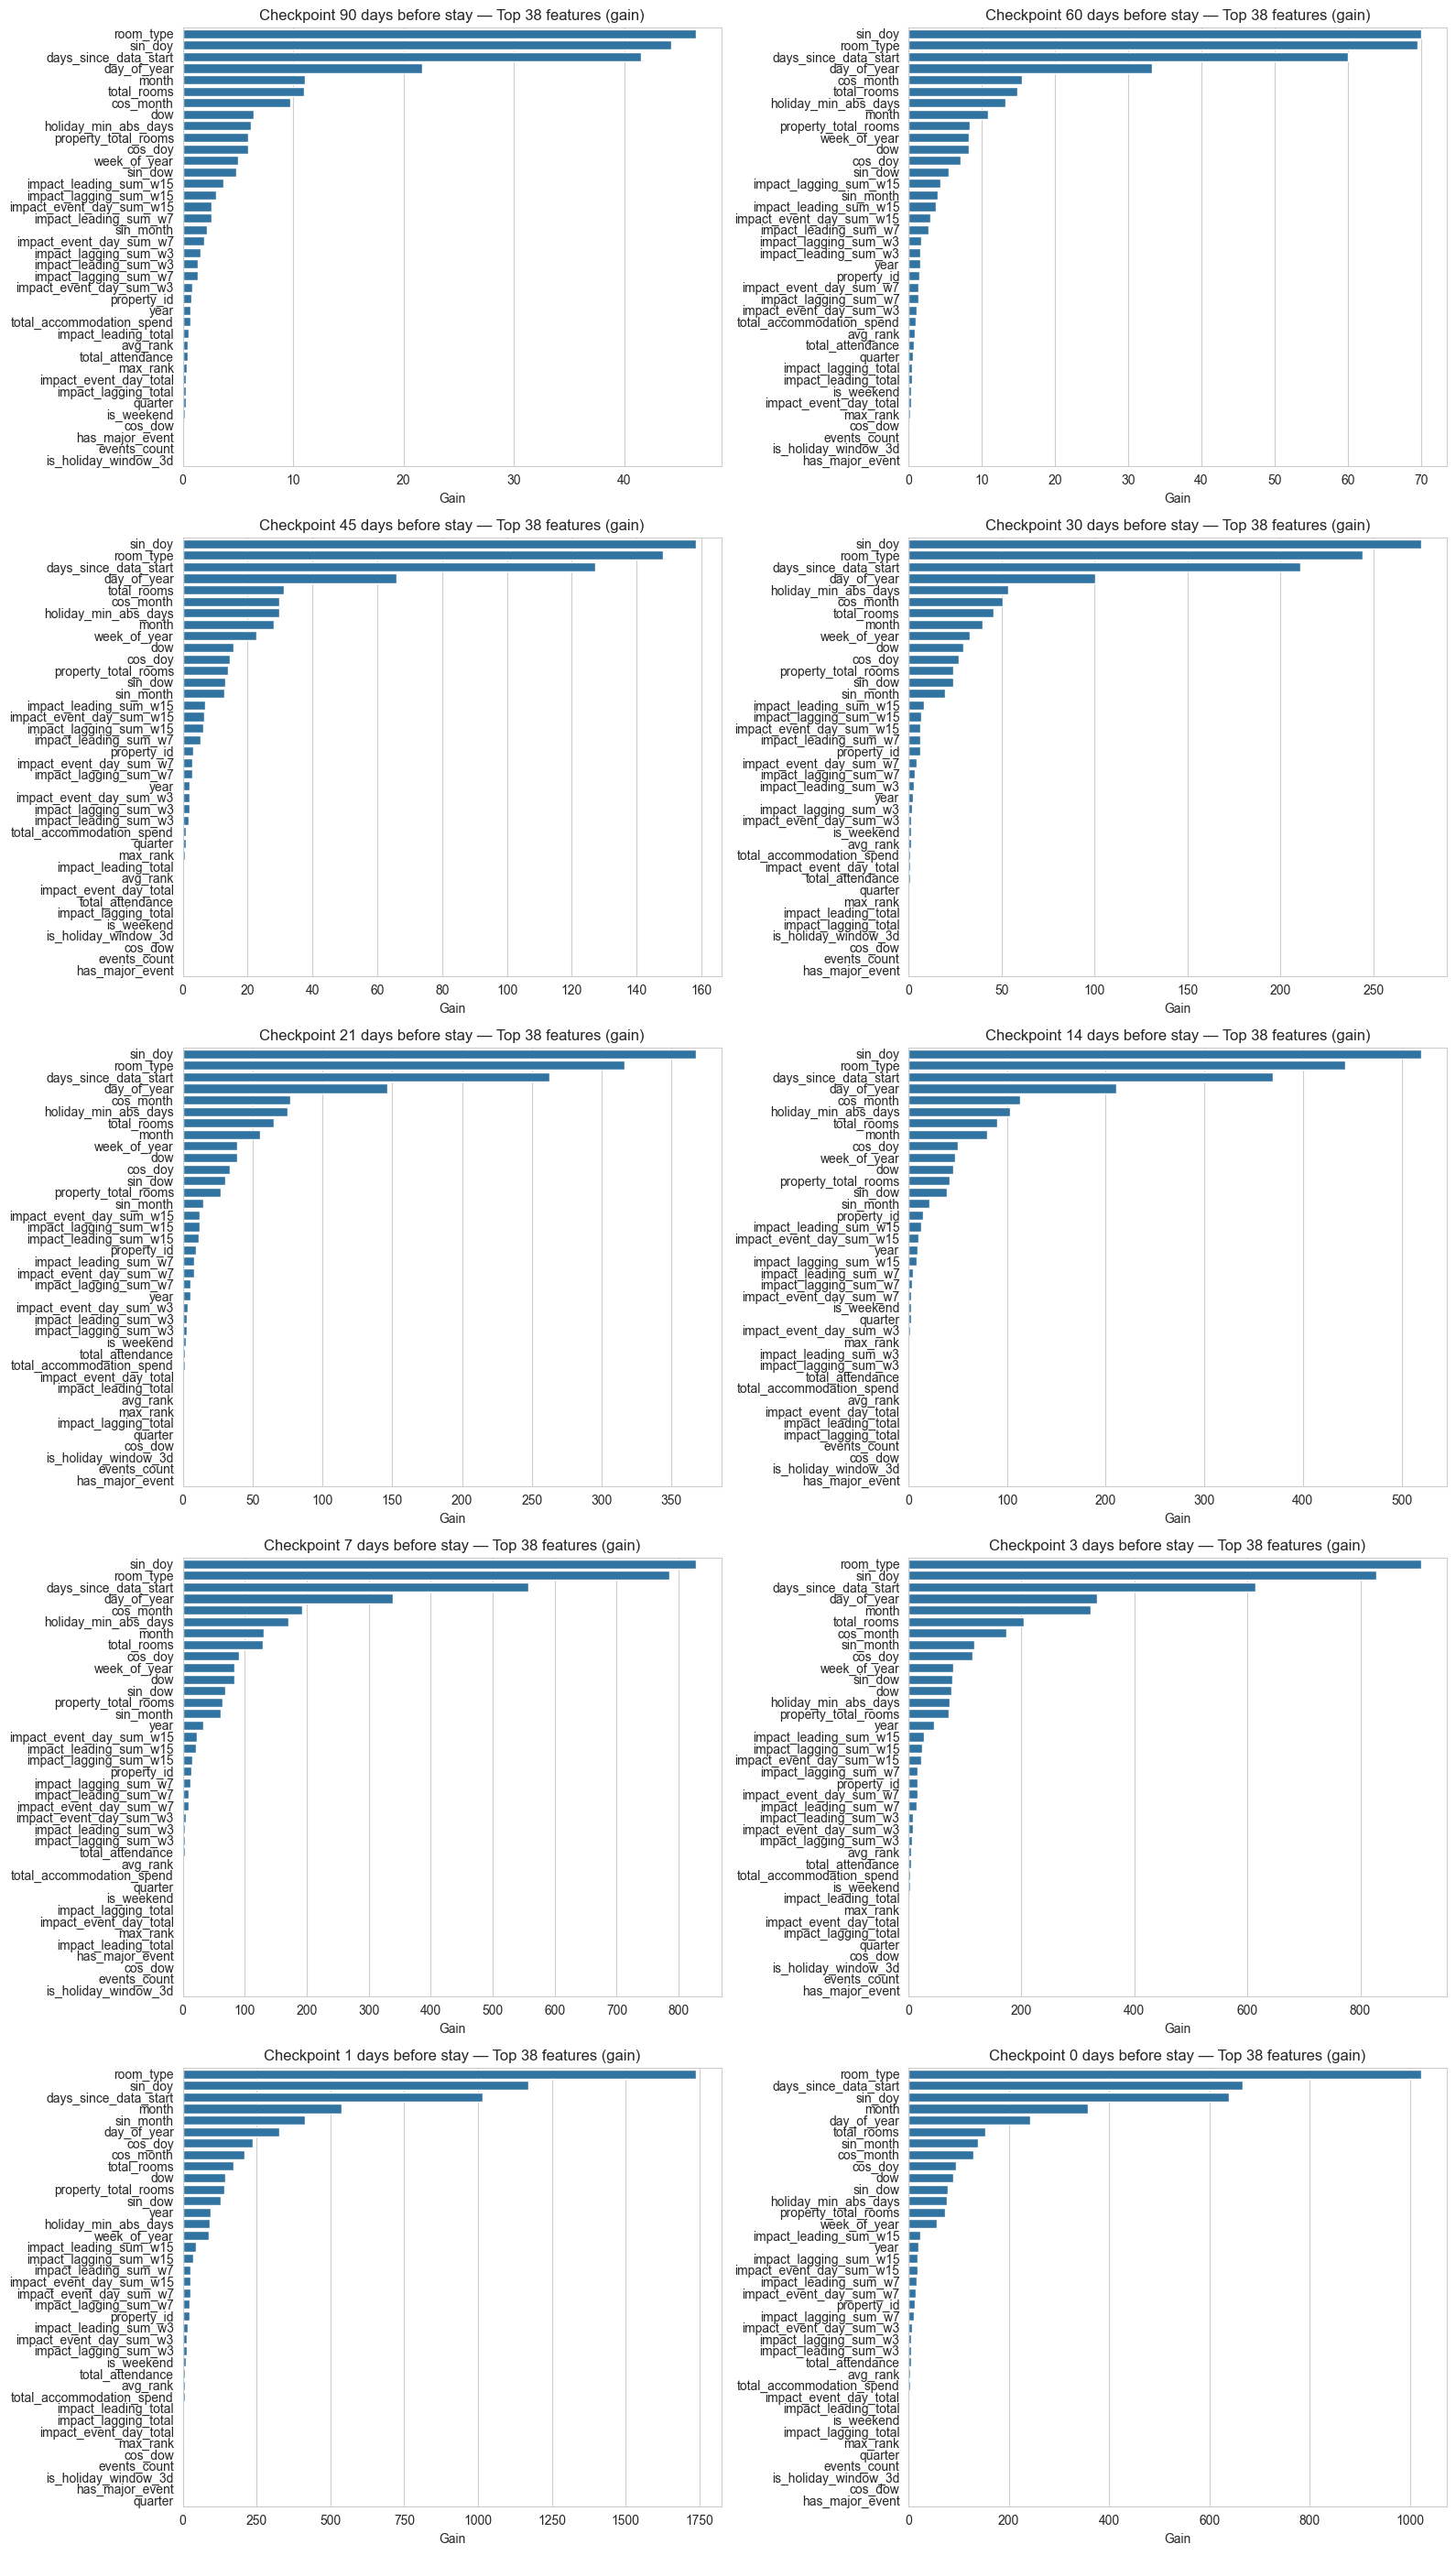

In [139]:
# --- Feature importance plots (one model per checkpoint) ---

TOP_K = 38

fig, axes = plt.subplots(5, 2, figsize=(16, 28))
axes = axes.ravel()

for ax, cp in zip(axes, CHECKPOINTS):
    model = models[cp]
    imp = model.booster_.feature_importance(importance_type='gain')
    fi = (
        pd.DataFrame({'feature': feature_names, 'gain': imp})
          .sort_values('gain', ascending=False)
          .head(TOP_K)
    )

    sns.barplot(data=fi, y='feature', x='gain', ax=ax, color='#1f77b4')
    ax.set_title(f'Checkpoint {cp} days before stay — Top {TOP_K} features (gain)')
    ax.set_xlabel('Gain')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()


In [ ]:
# Sorted feature importances + helper for top-N features

def feature_importance_df(models_dict, feature_names, checkpoint, importance_type='gain'):
    """Return feature-importance DataFrame sorted high->low for a chosen checkpoint."""
    if checkpoint not in models_dict:
        raise KeyError(f'Checkpoint {checkpoint} not found. Available: {sorted(models_dict.keys())}')

    model = models_dict[checkpoint]
    imp = model.booster_.feature_importance(importance_type=importance_type)
    fi = (
        pd.DataFrame({'feature': feature_names, 'importance': imp})
          .sort_values('importance', ascending=False)
          .reset_index(drop=True)
    )
    return fi


def top_n_features(models_dict, feature_names, checkpoint, n=25, importance_type='gain'):
    """Return top-n feature names (list[str]) for a chosen checkpoint."""
    fi = feature_importance_df(
        models_dict=models_dict,
        feature_names=feature_names,
        checkpoint=checkpoint,
        importance_type=importance_type,
    )
    return fi.head(n)['feature'].tolist()


# Example usage: choose checkpoint and inspect sorted importances
chosen_cp = 0
fi_sorted = feature_importance_df(models, feature_names, checkpoint=chosen_cp, importance_type='gain')

print(f'Sorted feature importances for checkpoint={chosen_cp} (high -> low):')
display(fi_sorted)

print(f'\nTop 25 features for checkpoint={chosen_cp}:')
print(top_n_features(models, feature_names, checkpoint=chosen_cp, n=25))


Sorted feature importances for checkpoint=0 (high -> low):


,feature,importance
0,room_type,1022.279160
1,days_since_data_start,666.215139
2,sin_doy,639.303072
3,month,357.803893
4,day_of_year,243.298061
5,total_rooms,153.938870
6,sin_month,139.233049
7,cos_month,128.951729
8,cos_doy,94.432408
9,dow,90.121564



Top 25 features for checkpoint=0:
['room_type', 'days_since_data_start', 'sin_doy', 'month', 'day_of_year', 'total_rooms', 'sin_month', 'cos_month', 'cos_doy', 'dow', 'sin_dow', 'holiday_min_abs_days', 'property_total_rooms', 'week_of_year', 'impact_leading_sum_w15', 'year', 'impact_lagging_sum_w15', 'impact_event_day_sum_w15', 'impact_leading_sum_w7', 'impact_event_day_sum_w7', 'property_id', 'impact_lagging_sum_w7', 'impact_event_day_sum_w3', 'impact_lagging_sum_w3', 'impact_leading_sum_w3']


## 9. Predict test curves

In [ ]:
# --- 8.4 Predict test curves + enforce monotonicity + save JSON ---

X_test, _ = prepare_X(test_wide, feature_cfg)

pred_mat = np.zeros((len(test_wide), len(CHECKPOINTS)), dtype=float)
for j, cp in enumerate(CHECKPOINTS):
    pred_mat[:, j] = models[cp].predict(X_test)

# Enforce non-decreasing curve from far-out -> near stay (90 ... 0)
pred_mat = np.maximum.accumulate(pred_mat, axis=1)
pred_mat = np.clip(pred_mat, 0.0, 1.0)

predictions = []
for i, row in test_wide.reset_index(drop=True).iterrows():
    preds = {str(cp): float(pred_mat[i, j]) for j, cp in enumerate(CHECKPOINTS)}
    predictions.append(
        {
            'property_id': row['property_id'],
            'room_type': row['room_type'],
            'stay_date': pd.Timestamp(row['stay_date']).strftime('%Y-%m-%d'),
            'predictions': preds,
        }
    )

# out_path = Path('../evaluation/Predictions/predictions_LGBM_base_feats.json')
# out_path = Path('../evaluation/Predictions/predictions_LGBM_base_feats_CV.json')
# out_path = Path('../evaluation/Predictions/predictions_LGBM_base_feats_with_events_CV.json')
out_path = Path('../evaluation/Predictions/predictions_LGBM_base_feats_with_events_w3714_top25_CV.json')

with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(predictions, f, indent=2)

print(f'Saved {len(predictions):,} predictions to {out_path}')
print('Run evaluation:')
print(f'  python ../evaluation/evaluate.py --predictions {out_path.as_posix()}')


Saved 1,012 predictions to ..\evaluation\Predictions\predictions_LGBM_base_feats_with_events_w3714_top25_CV.json
Run evaluation:
  python ../evaluation/evaluate.py --predictions ../evaluation/Predictions/predictions_LGBM_base_feats_with_events_w3714_top25_CV.json


## 10. XGBoost training loop (time-based CV + early stopping)

This section mirrors the LightGBM flow using **XGBoost**:

1. Use time-based validation folds in the training period.
2. For each checkpoint model, run a compact parameter search with early stopping.
3. Select best parameters by average CV MAE.
4. Refit on full train window with tuned settings.
5. Plot per-checkpoint feature importances and export test predictions.

In [155]:
# If needed in your environment
%pip install -q xgboost

import xgboost as xgb


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Prepare X + (re)build time-based folds for XGBoost

import xgboost as xgb
from sklearn.metrics import mean_absolute_error

X_all_xgb, feature_names_xgb = prepare_X(train_wide, feature_cfg)

# Make categorical columns explicit if present (for XGBoost native categorical splits)
for c in getattr(feature_cfg, 'categorical_features', []):
    if c in X_all_xgb.columns:
        X_all_xgb[c] = X_all_xgb[c].astype('category')

# Reuse existing folds if they exist; otherwise rebuild with same windows as LGBM section
if 'folds' not in globals() or len(folds) == 0:
    fold_specs = [
        (pd.Timestamp('2025-01-01'), pd.Timestamp('2025-02-28')),
        (pd.Timestamp('2025-03-01'), pd.Timestamp('2025-04-30')),
        (pd.Timestamp('2025-05-01'), pd.Timestamp('2025-06-30')),
    ]
    folds = []
    stay_dates = pd.to_datetime(train_wide['stay_date'])
    for val_start, val_end in fold_specs:
        tr_idx = train_wide.index[stay_dates < val_start]
        va_idx = train_wide.index[(stay_dates >= val_start) & (stay_dates <= val_end)]
        if len(tr_idx) > 0 and len(va_idx) > 0:
            folds.append((tr_idx, va_idx, val_start, val_end))

print(f'Built/Reused {len(folds)} time folds for XGBoost')
for i, (tr_idx, va_idx, vs, ve) in enumerate(folds, 1):
    print(f' Fold {i}: train={len(tr_idx):,} | val={len(va_idx):,} | val_window=[{vs.date()}..{ve.date()}]')

Built/Reused 3 time folds for XGBoost
 Fold 1: train=12,056 | val=649 | val_window=[2025-01-01..2025-02-28]
 Fold 2: train=12,705 | val=671 | val_window=[2025-03-01..2025-04-30]
 Fold 3: train=13,376 | val=671 | val_window=[2025-05-01..2025-06-30]


In [ ]:
# Tune per checkpoint with CV + early stopping (XGBoost)

param_grid_xgb = [
    dict(learning_rate=0.05, max_depth=6, min_child_weight=5, subsample=0.8, colsample_bytree=0.8),
    dict(learning_rate=0.05, max_depth=8, min_child_weight=3, subsample=0.8, colsample_bytree=0.8),
    dict(learning_rate=0.03, max_depth=8, min_child_weight=2, subsample=0.9, colsample_bytree=0.9),
]

base_params_xgb = dict(
    n_estimators=3000,
    objective='reg:squarederror',
    eval_metric='mae',
    random_state=42,
    tree_method='hist',
    enable_categorical=True,
    reg_alpha=0.1,
    reg_lambda=0.1,
)

checkpoint_tuning_xgb = []
best_params_by_cp_xgb = {}
best_iter_by_cp_xgb = {}

for cp in CHECKPOINTS:
    y_all = train_wide[f'cp_{cp}'].astype(float)
    best_score = np.inf
    best_cfg = None
    best_iters = []

    for cfg in param_grid_xgb:
        fold_maes = []
        fold_iters = []

        for tr_idx, va_idx, _, _ in folds:
            X_tr = X_all_xgb.loc[tr_idx]
            y_tr = y_all.loc[tr_idx].values
            X_va = X_all_xgb.loc[va_idx]
            y_va = y_all.loc[va_idx].values

            model = xgb.XGBRegressor(**base_params_xgb, **cfg, early_stopping_rounds=100,)
            model.fit(
                X_tr,
                y_tr,
                eval_set=[(X_va, y_va)],
                verbose=False,
                # early_stopping_rounds=100,
            )

            best_iter = int(getattr(model, 'best_iteration', 0) or 0) + 1
            pred_va = model.predict(X_va, iteration_range=(0, best_iter))
            fold_maes.append(mean_absolute_error(y_va, pred_va))
            fold_iters.append(best_iter)

        cv_mae = float(np.mean(fold_maes))
        if cv_mae < best_score:
            best_score = cv_mae
            best_cfg = cfg.copy()
            best_iters = fold_iters[:]

    best_params_by_cp_xgb[cp] = best_cfg
    best_iter_by_cp_xgb[cp] = int(np.median(best_iters)) if len(best_iters) else 600
    checkpoint_tuning_xgb.append({
        'checkpoint': cp,
        'cv_mae': best_score,
        'best_iter_median': best_iter_by_cp_xgb[cp],
        **best_cfg,
    })

tuning_df_xgb = pd.DataFrame(checkpoint_tuning_xgb).sort_values('checkpoint', ascending=False)
display(tuning_df_xgb)

,checkpoint,cv_mae,best_iter_median,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree
0,90,0.043394,76,0.05,6,5,0.8,0.8
1,60,0.048920,88,0.05,6,5,0.8,0.8
2,45,0.059051,71,0.05,6,5,0.8,0.8
3,30,0.068604,70,0.05,6,5,0.8,0.8
4,21,0.076158,83,0.05,6,5,0.8,0.8
5,14,0.083627,73,0.05,6,5,0.8,0.8
6,7,0.087749,135,0.05,6,5,0.8,0.8
7,3,0.080662,86,0.05,6,5,0.8,0.8
8,1,0.072534,150,0.03,8,2,0.9,0.9
9,0,0.068958,126,0.05,6,5,0.8,0.8


In [ ]:
# Refit final XGBoost models on full train window

models_xgb: Dict[int, xgb.XGBRegressor] = {}

for cp in CHECKPOINTS:
    y = train_wide[f'cp_{cp}'].astype(float).values

    cfg = best_params_by_cp_xgb[cp]
    n_best = int(best_iter_by_cp_xgb[cp])

    # Merge params once, then override n_estimators explicitly
    params = {**base_params_xgb, **cfg}
    params["n_estimators"] = max(n_best, 50)

    model = xgb.XGBRegressor(**params)
    model.fit(X_all_xgb, y, verbose=False)
    models_xgb[cp] = model

print('Tuned XGBoost checkpoints:', list(models_xgb.keys()))

Tuned XGBoost checkpoints: [90, 60, 45, 30, 21, 14, 7, 3, 1, 0]


### 10.1 XGBoost feature importances (per checkpoint model)

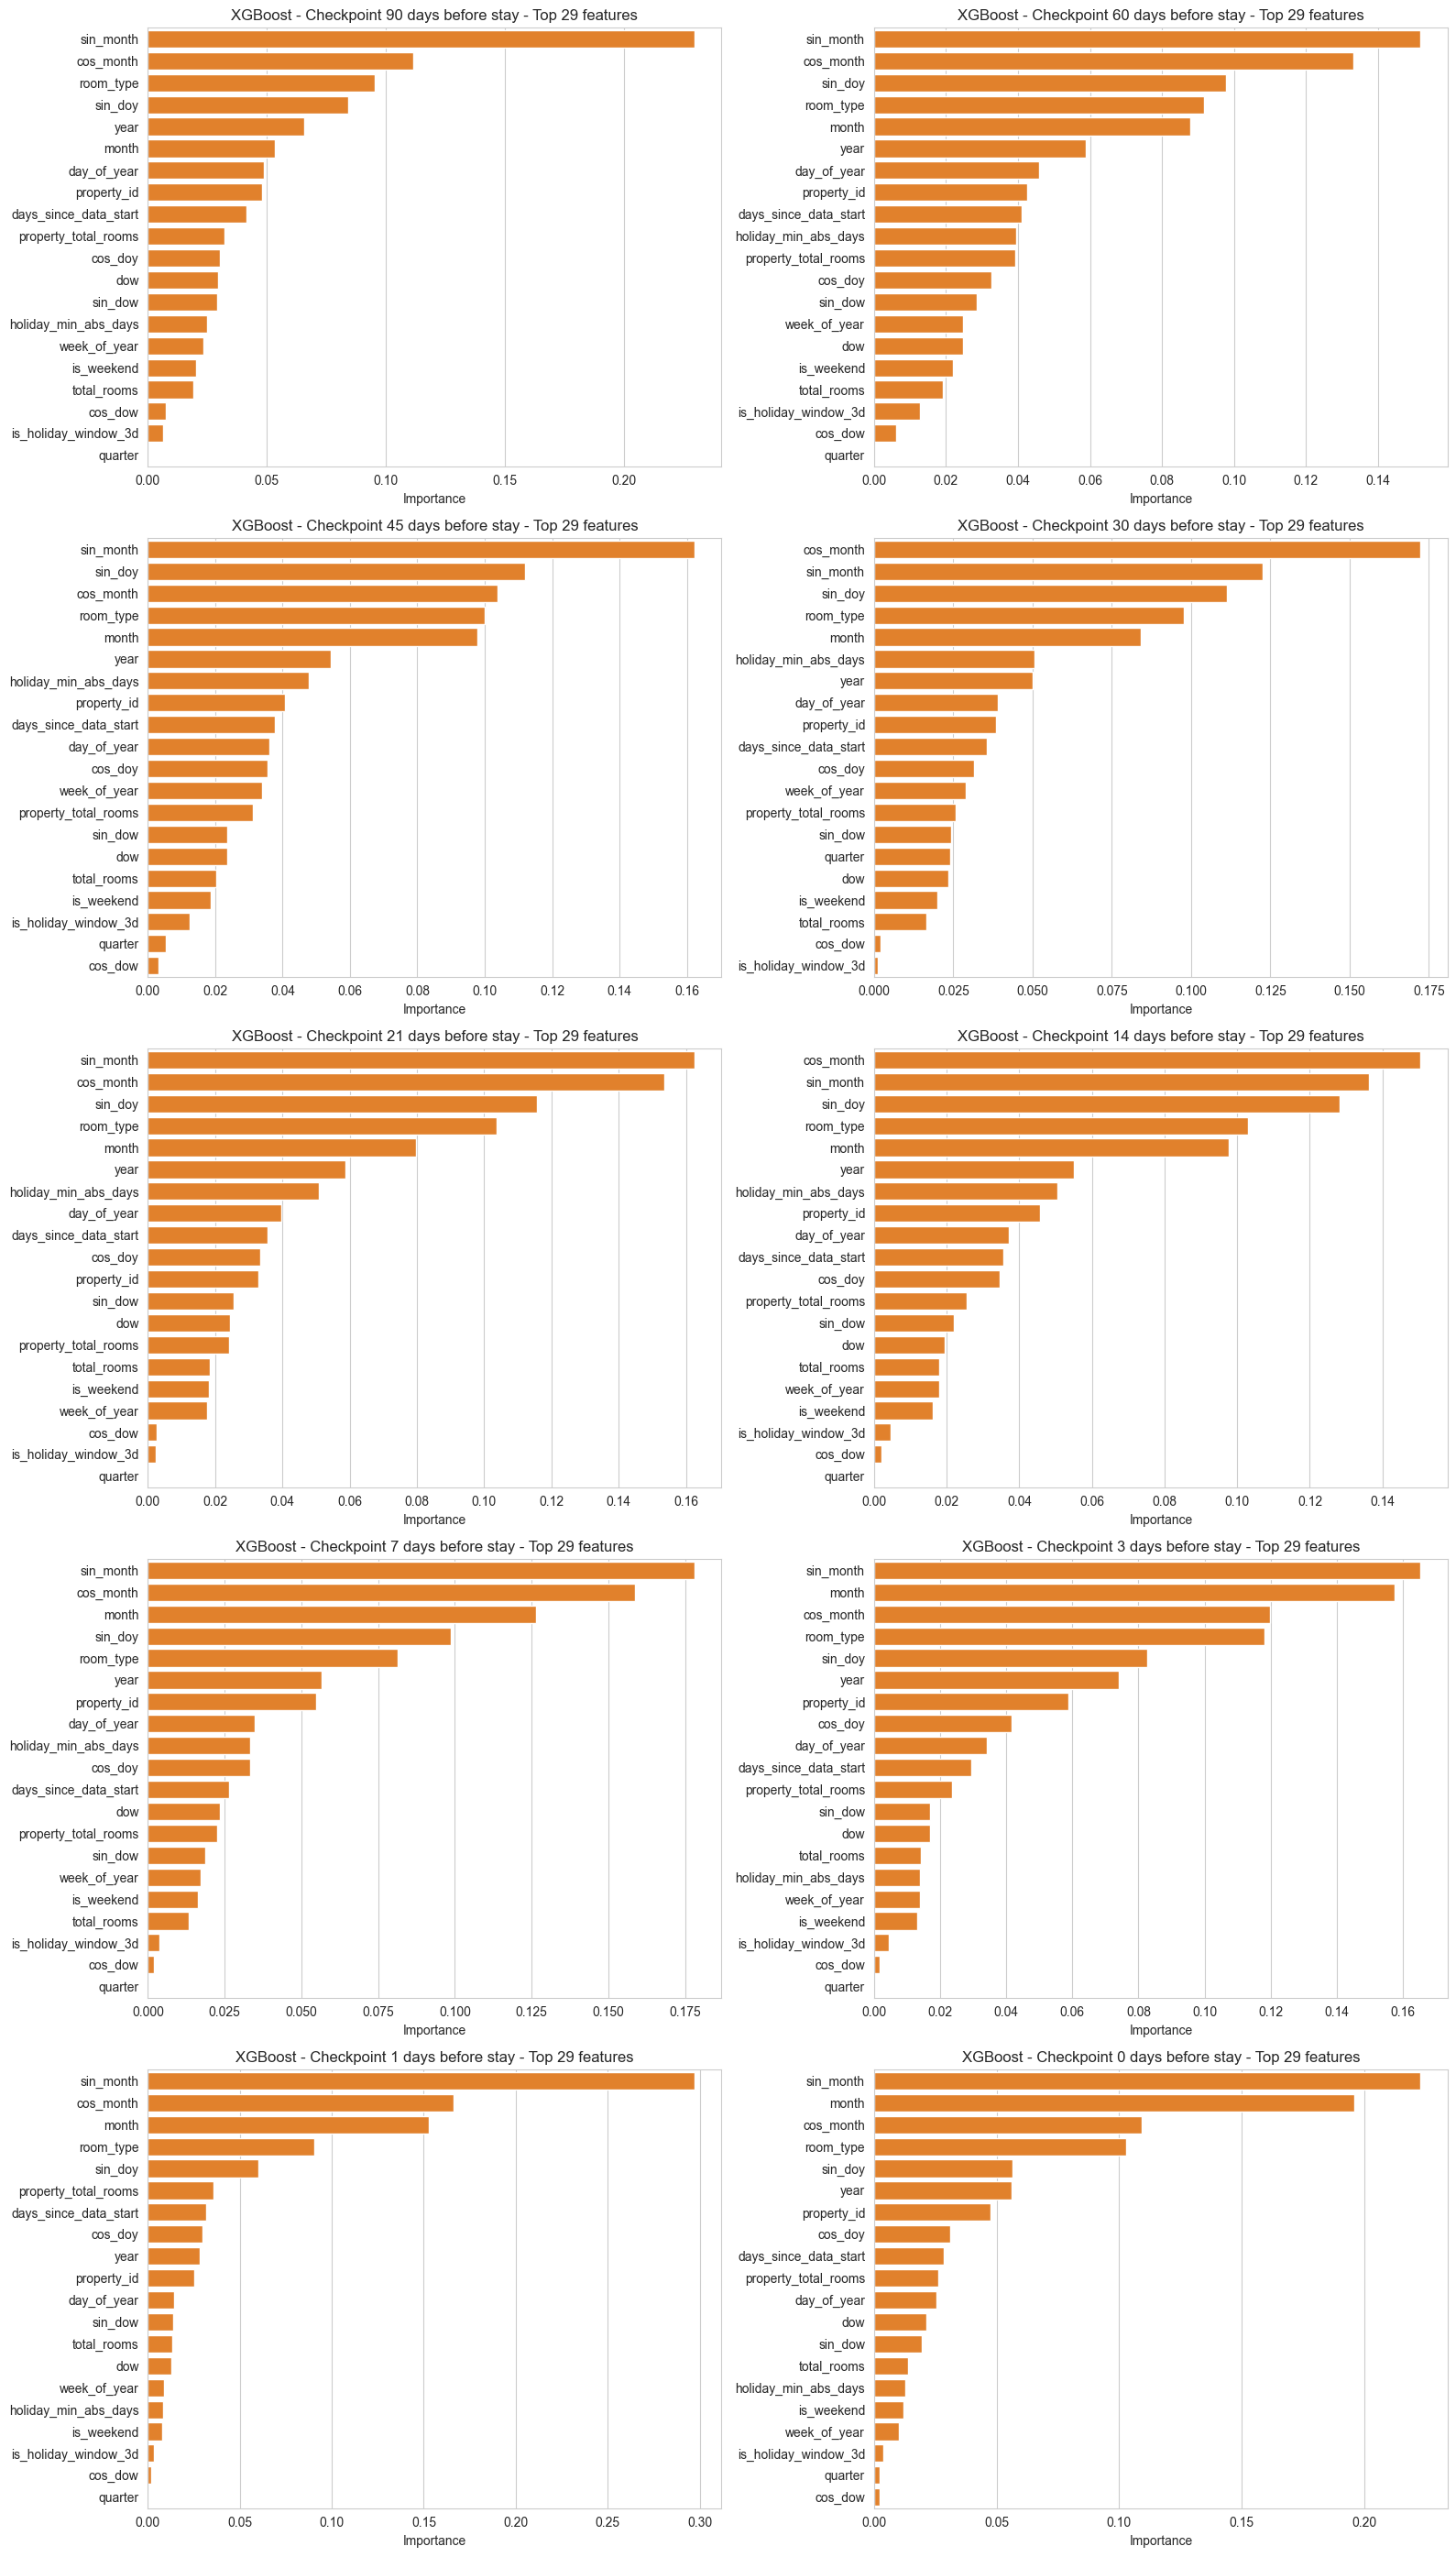

Sorted XGBoost feature importances for checkpoint=14 (high -> low):


,feature,importance
0,cos_month,0.150449
1,sin_month,0.136200
2,sin_doy,0.128277
3,room_type,0.103012
4,month,0.097704
5,year,0.054950
6,holiday_min_abs_days,0.050399
7,property_id,0.045803
8,day_of_year,0.037245
9,days_since_data_start,0.035611



Top 15 XGBoost features for checkpoint=14:
['cos_month', 'sin_month', 'sin_doy', 'room_type', 'month', 'year', 'holiday_min_abs_days', 'property_id', 'day_of_year', 'days_since_data_start', 'cos_doy', 'property_total_rooms', 'sin_dow', 'dow', 'total_rooms']


In [ ]:
# XGBoost feature importance plots (one model per checkpoint)

TOP_K_XGB = 29

fig, axes = plt.subplots(5, 2, figsize=(16, 28))
axes = axes.ravel()

for ax, cp in zip(axes, CHECKPOINTS):
    model = models_xgb[cp]
    imp = model.feature_importances_
    fi = (
        pd.DataFrame({'feature': feature_names_xgb, 'gain': imp})
          .sort_values('gain', ascending=False)
          .head(TOP_K_XGB)
    )

    sns.barplot(data=fi, y='feature', x='gain', ax=ax, color='#ff7f0e')
    ax.set_title(f'XGBoost - Checkpoint {cp} days before stay - Top {TOP_K_XGB} features')
    ax.set_xlabel('Importance')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()


# --- Sorted importances + helper to get top-n feature names for chosen checkpoint ---
def feature_importance_df_xgb(models_dict, feature_names, checkpoint):
    if checkpoint not in models_dict:
        raise KeyError(f'Checkpoint {checkpoint} not found. Available: {sorted(models_dict.keys())}')

    imp = models_dict[checkpoint].feature_importances_
    return (
        pd.DataFrame({'feature': feature_names, 'importance': imp})
          .sort_values('importance', ascending=False)
          .reset_index(drop=True)
    )


def top_n_features_xgb(models_dict, feature_names, checkpoint, n=15):
    fi = feature_importance_df_xgb(models_dict, feature_names, checkpoint=checkpoint)
    return fi.head(n)['feature'].tolist()


chosen_cp_xgb = 14
fi_sorted_xgb = feature_importance_df_xgb(models_xgb, feature_names_xgb, checkpoint=chosen_cp_xgb)

print(f'Sorted XGBoost feature importances for checkpoint={chosen_cp_xgb} (high -> low):')
display(fi_sorted_xgb)
print(f'\nTop 15 XGBoost features for checkpoint={chosen_cp_xgb}:')
print(top_n_features_xgb(models_xgb, feature_names_xgb, checkpoint=chosen_cp_xgb, n=15))

In [ ]:
# Predict test curves with XGBoost + enforce monotonicity + save JSON

X_test_xgb, _ = prepare_X(test_wide, feature_cfg)
for c in getattr(feature_cfg, 'categorical_features', []):
    if c in X_test_xgb.columns:
        X_test_xgb[c] = X_test_xgb[c].astype('category')

pred_mat_xgb = np.zeros((len(test_wide), len(CHECKPOINTS)), dtype=float)
for j, cp in enumerate(CHECKPOINTS):
    pred_mat_xgb[:, j] = models_xgb[cp].predict(X_test_xgb)

# Enforce non-decreasing curve from far-out -> near stay (90 ... 0)
pred_mat_xgb = np.maximum.accumulate(pred_mat_xgb, axis=1)
pred_mat_xgb = np.clip(pred_mat_xgb, 0.0, 1.0)

predictions_xgb = []
for i, row in test_wide.reset_index(drop=True).iterrows():
    preds = {str(cp): float(pred_mat_xgb[i, j]) for j, cp in enumerate(CHECKPOINTS)}
    predictions_xgb.append(
        {
            'property_id': row['property_id'],
            'room_type': row['room_type'],
            'stay_date': pd.Timestamp(row['stay_date']).strftime('%Y-%m-%d'),
            'predictions': preds,
        }
    )

out_path_xgb = Path('../evaluation/Predictions/predictions_XGB_base_feats_CV.json')
with open(out_path_xgb, 'w', encoding='utf-8') as f:
    json.dump(predictions_xgb, f, indent=2)

print(f'Saved {len(predictions_xgb):,} XGBoost predictions to {out_path_xgb}')
print('Run evaluation:')
print(f'  python ../evaluation/evaluate.py --predictions {out_path_xgb.as_posix()}')

Saved 1,012 XGBoost predictions to ..\evaluation\Predictions\predictions_XGB_base_feats_CV.json
Run evaluation:
  python ../evaluation/evaluate.py --predictions ../evaluation/Predictions/predictions_XGB_base_feats_CV.json
